<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Комментарий ревьюера v1</h1>

Екатерина, привет! Меня зовут Дмитрий, и я буду проверять твой проект. Предлагаю общаться на «ты» если ты не против 😊 Но если нет, то дай знать, и мы перейдем на "вы". 
    
Для своих комментариев я буду использовать цветовую разметку:

<div class="alert alert-success">
    <b>Успех:</b> все сделано правильно.
</div>
<div class="alert alert-warning">
    <b>Есть замечания:</b> так выделены небольшие замечания которые не критичны, но было бы здорово исправить. Если таких замечаний немного, то такой проект может быть принят.
</div>
<div class="alert alert-danger">
    <b>Нужно переделать:</b> есть замечания которые необходимо исправить или доделать для сдачи проекта.
</div>
    
Я буду поддерживать версионность комментариев, и при следующих итерациях я буду оставлять ячейки с новой версией v2 (v3 и.т.д.)
    
Если у тебя есть вопросы, замечания или отвечаешь на комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии: 
<div class="alert alert-info"> <b>Комментарий студента:</b></div>


<div style="border:solid green 2px; padding: 20px">
<b>Комментарий ревьюера v1:</b>
    
<b>Общее впечатление:</b> 
 
Отличная работа по разработке модели машинного обучения для задачи регрессии — прогнозирования спроса на аренду велосипедов! Ты продемонстрировала владение продвинутым инструментарием: грамотное использование sklearn Pipeline и ColumnTransformer, глубокий анализ зависимостей и автоматический подбор гиперпараметров с помощью Optuna.

Модель разработана с явным пониманием алгоритмов: ты правильно разделила предобработку для kNN (с масштабированием) и Деревьев решений, что критически важно для корректного сравнения. Структура ноутбука логична, код чист и воспроизводим, а выводы опираются на цифры. Особенно ценно, что ты провела честное сравнение с Baseline-моделью и доказала эффективность нелинейных подходов.
    
Критических замечаний нет - проект принят! Желаю успехов в следующих спринтах и дальнейшего развития в машинном обучении! 🚀
    
На будущее обрати внимание на несколько идей для улучшения:
- Встроенный метод `corr` автоматически игнорирует пропуски, про это важно помнить при построении конвейера предобработки.
- Для метода ближайших соседей можно попробовать применить стандартизацию ко всем признакам, включая бинарные, чтобы посмотреть на изменение качества прогноза.
- Оптимизированный конвейер сейчас обучается только на урезанной выборке `X_tr`. Перед сохранением и финальной оценкой рекомендуется вызвать метод `fit` на полных массивах обучающей выборки `X_train` и `y_train`.
- Проверка загрузки модели через вызов `joblib.load()` в той же сессии не гарантирует корректную загрузку в независимом окружении. Для честной проверки стоит перезагружать ядро.

 
PS:  если хочешь глубже разобраться в том, как под капотом работают деревья решений и kNN, очень советую почитать Тему 3 из Открытого курса машинного обучения (ODS) на Хабре: https://habr.com/ru/companies/ods/articles/322534/

Также рекомендую книгу Мюллера и Гвидо «Введение в машинное обучение с помощью Python». Она написана одним из создателей библиотеки <code>scikit-learn</code> и отлично помогает при создании пайплайнов!       
    
</div>

# **🚴‍♀️ Проект спринта: Нелинейные модели против сочинской погоды**

Компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды.

До этого аналитики компании использовали простую линейную регрессию — одну из самых базовых моделей машинного обучения.

Однако её прогнозы часто ошибались:



> «Модель видела, что температура выросла — и сразу предсказывала высокий спрос.
Но не понимала, что +28 °C под палящим солнцем и +28 °C после дождя — это две совсем разные ситуации.»

Погода в Сочи меняется быстро, и влияние факторов — нелинейное: температура, влажность, солнечная радиация, осадки влияют на поведение людей не по простым прямым зависимостям.



---



В рамках этого проекта вы выступаете в роли аналитиков компании **BikeSochi, которые должны предложить новую, более гибкую модель прогнозирования.**

**В этом проекте вы:**

1. Изучите предоставленную компанией baseline-модель (линейную регрессию);

2. Обучите новые модели — K-ближайших соседей (KNN) и решающее дерево (Decision Tree);

3. Проведёте подбор гиперпараметров с помощью библиотеки Optuna;

4. Сравните результаты всех подходов, выберете наилучший и аргументируете свой выбор.

Дополнительно: Реализуете собственный класс-трансформер и интегрируете его в пайплайн.


**К концу проекта у вас будет:**

— улучшенная модель прогноза почасового спроса на велосипеды в Сочи;

— отчёт с метриками и сравнением подходов;

— сохранённый пайплайн лучшей модели.



---



# **Часть 1: Базовая модель**

В этой части вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSochi до внедрения улучшенной версии.

Компания предоставила вам:

— baseline_linear_regression_pipeline.pkl — готовый обученный пайплайн (без исходного кода);

— краткое описание того, как он был устроен;

— тренировочную и тестовую выборки, которые можно использовать для оценки модели.

Это значит, что вам не нужно обучать эту модель заново — вы просто загружаете её и проверяете качество (например, на метриках RMSE, MAE, R²).

**Совет:**
1. Убедитесь, что у вас есть baseline_linear_regression_pipeline.pkl и train_data.csv и test_data.csv.

2. Разделите тестовый набор на признаки (X) и целевую переменную Rented Bike Count.

3. Загрузите .pkl файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R², эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

# **Часть 2: Улучшение модели — KNN и Decision Tree**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы сочинской погоды и поведение клиентов.

Вы будете экспериментировать с K-ближайшими соседями (KNN) и решающим деревом (Decision Tree), использовать подбор гиперпараметров с Optuna и внедрять кастомные трансформеры для новых признаков.

**Шаг 1: Изучение постановки задачи:**

Проведите EDA (Exploratory Data Analysis):
1. Посмотрите на распределение целевой переменной Rented Bike Count. Есть ли выбросы или сильные сезонные колебания?
2. Постройте графики зависимости спроса от температуры, осадков, солнечной радиации.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Проверьте корреляции между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять. Начните с базовых графиков и описательной статистики.



---



**Шаг 2: Разделение данных на тренировочную и валидационную выборки**

> У вас есть доступ к тренировочной и тестовой выборкам.

Тестовый набор используется для финальной оценки модели после тренировки и подбора гиперпараметров.

Вы тренируетесь на тренировочных данных и оцениваете качество через валидацию.

---



**Шаг 3: Обучение новых моделей**

> Теперь пора «проверить, насколько далеко уедут модели» — KNN и Decision Tree могут уловить нелинейные зависимости, недоступные линейной регрессии.

Что нужно сделать:
1. Подготовьте пайплайн для каждой модели:
    * Предобработка данных.
    * Модель (KNN или Decision Tree).
4. Настройте базовые параметры моделей (например, n_neighbors для KNN, max_depth для дерева).

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров делаем на следующем шаге.

---



**Шаг 4: Подбор гиперпараметров с Optuna**

> Компания хочет точную модель. Optuna поможет найти лучшие параметры для KNN и дерева, чтобы снизить ошибки прогноза.

Что нужно сделать:
1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь экспериментировать с небольшими диапазонами сначала, а потом расширять, если модель «не уловила» зависимости.

---



**Шаг 5: Кросс-валидация новых моделей**

Что нужно сделать:
1. Проведите кросс-валидацию для KNN и Decision Tree с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (bar plot, box plot), чтобы увидеть разброс метрик и стабильность моделей.


---



**Шаг 6: Составление отчёта по моделям**

Что нужно сделать:
1. Составьте таблицу с метриками: baseline, KNN, Decision Tree.
2. Добавьте визуализацию, если необходимо: bar plot или box plot по RMSE/MAE.

Подготовьте выводы:
1. Какая модель лучше справляется с прогнозом?
2. Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте: «Эта модель лучше реагирует на дождь», «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7: Сохранение модели и отчёта**

Что нужно сделать:
1. Выберите финальную, наилучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько она прогнозирует реальные данные.
2. Подготовьте ноутбук с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг: почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче это помогает коллегам и руководству понимать решения и доверять модели.

---



**Опционально: Реализация кастомного трансформера**

> Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию.
Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

Что нужно сделать:
1. Реализуйте класс с методами fit и transform.
2. Вставьте его в пайплайн перед моделью.
3. Проверьте, что трансформер корректно работает с тренировочными данными.

**Совет:**
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---



 # **Авторское решение**

______________________
## **Часть 1: Базовая модель Загрузка baseline-пайплайна.**  
1.1. Подготовка окружения. Загружаем baseline-модель компании из файла baseline_linear_regression_pipeline.joblib.

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Окружение и библиотеки загружены корректно. Отличная работа с версиями.
</div>

In [1]:
# =============================================================================
# 1.1 Подготовка окружения
# =============================================================================
# Baseline-модель компании сохранена в окружении со scikit-learn 1.6.1 
# и numpy >= 1.26. Устанавливаем совместимые версии:
%pip install "numpy==1.26.4" "pandas==2.1.4" "scipy==1.11.4" "scikit-learn==1.6.1" "joblib==1.3.2" "optuna>=3.6.0"

# =============================================================================
# 1.2 Импорты и воспроизводимость
# =============================================================================
# Стандартная библиотека Python 
import os
import json
import random
import warnings

# Основные библиотеки для работы с данными 
import numpy as np
import pandas as pd
import scipy
import sklearn
import joblib


# Визуализация 
import matplotlib.pyplot as plt
import seaborn as sns

# Работа с моделями и пайплайнами sklearn 
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
)
from sklearn.impute import SimpleImputer

# Модели 
from sklearn.linear_model import LinearRegression #
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Метрики и кросс-валидация 
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    KFold,
)


# Оптимизация гиперпараметров 
import optuna

# Настройки вывода 
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING) #  Отключаем подробный лог Optuna (оставляем только важное) 

# =============================================================================
# Воспроизводимость
# =============================================================================
RANDOM_STATE = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# =============================================================================
# Проверка версий окружения
# =============================================================================
print(f"numpy:        {np.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"scipy:        {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"joblib:       {joblib.__version__}")
print(f"optuna:       {optuna.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}") 

Note: you may need to restart the kernel to use updated packages.
numpy:        1.26.4
pandas:       2.1.4
scipy:        1.11.4
scikit-learn: 1.6.1
joblib:       1.3.2
optuna:       5.0.0
RANDOM_STATE = 42


In [2]:
# Данные
train_df = pd.read_csv('ds_s14_train_data.csv')
test_df  = pd.read_csv('ds_s14_test_data.csv')

# Baseline-модель
baseline_model = joblib.load('baseline_linear_regression_pipeline.joblib')

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("Тип модели:", type(baseline_model))
print("\nКолонки train:")
for col in train_df.columns:
    print(f"  • {col}  ({train_df[col].dtype})")

Train shape: (7008, 16)
Test shape:  (1752, 16)
Тип модели: <class 'sklearn.pipeline.Pipeline'>

Колонки train:
  • Temperature  (float64)
  • Humidity(%)  (float64)
  • Wind speed (m/s)  (float64)
  • Visibility (10m)  (float64)
  • Dew point temperature  (float64)
  • Solar Radiation (MJ/m2)  (float64)
  • Rainfall(mm)  (float64)
  • Snowfall (cm)  (float64)
  • Seasons  (object)
  • Holiday  (object)
  • Functioning Day  (object)
  • Time_Period_Evening  (bool)
  • Time_Period_Late Evening  (bool)
  • Time_Period_Morning  (bool)
  • Time_Period_Night  (bool)
  • Rented Bike Count  (int64)


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Данные успешно загружены, базовая модель считана из файла.
</div>

Первичный просмотр данных

Смотрим первые строки и убеждаемся, что данные распарсились корректно.

In [3]:
# Первые строки обучающей выборки
print("ПЕРВЫЕ 10 СТРОК ОБУЧАЮЩЕЙ ВЫБОРКИ")
display(train_df.head(10))

# Первые строки тестовой выборки
print("ПЕРВЫЕ 5 СТРОК ТЕСТОВОЙ ВЫБОРКИ")
display(test_df.head(5))

ПЕРВЫЕ 10 СТРОК ОБУЧАЮЩЕЙ ВЫБОРКИ


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686
5,9.7,76.0,0.0,1308.0,5.6,0.00,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,True,157
6,17.4,49.0,1.2,2000.0,6.5,0.00,0.0,0.0,Autumn,Holiday,Yes,False,True,False,False,1042
7,18.1,60.0,0.2,2000.0,10.2,0.00,0.0,0.0,Autumn,No Holiday,No,False,False,False,True,0
8,36.7,33.0,1.8,1911.0,17.7,3.24,0.0,0.0,Summer,No Holiday,Yes,False,False,False,False,569
9,7.0,57.0,0.7,1553.0,-0.9,0.79,0.0,0.0,Autumn,No Holiday,Yes,False,False,True,False,1027


ПЕРВЫЕ 5 СТРОК ТЕСТОВОЙ ВЫБОРКИ


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Первичный осмотр данных проведён правильно.
</div>

1.2. Анализ устройства baseline-пайплайна

Изучаем внутреннее строение пайплайна компании: какие трансформеры применяются 
к каким группам признаков.

In [4]:
# Анализ устройства baseline-пайплайна
for i, (name, step) in enumerate(baseline_model.steps, 1):
    print(f"{i}. {name}: {type(step).__name__}")
    if hasattr(step, 'steps'):
        for j, (n2, s2) in enumerate(step.steps, 1):
            print(f"     {i}.{j}. {n2}: {type(s2).__name__}")

# Препроцессор
preprocessor = baseline_model.named_steps['preprocessor']

print("\nColumnTransformer ожидает колонки:")
print(preprocessor.feature_names_in_)

print("\nВнутренние трансформеры:")
for name, transformer, columns in preprocessor.transformers_:
    print(f"  • {name}: {type(transformer).__name__}")
    print(f"    Колонки: {list(columns) if hasattr(columns, '__iter__') else columns}")

1. preprocessor: ColumnTransformer
2. model: LinearRegression

ColumnTransformer ожидает колонки:
['temperature' 'humidity' 'wind_speed_ms' 'visibility_10m'
 'dew_point_temperature' 'solar_radiation_mjm2' 'rainfallmm' 'snowfall_cm'
 'seasons' 'holiday' 'functioning_day' 'time_period_evening'
 'time_period_late_evening' 'time_period_morning' 'time_period_night']

Внутренние трансформеры:
  • num: Pipeline
    Колонки: ['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm']
  • cat: Pipeline
    Колонки: ['seasons', 'holiday', 'functioning_day']
  • time: FunctionTransformer
    Колонки: ['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Ты детально разобрала устройство загруженного конвейера, это поможет в дальнейшем.
</div>

Приведение имён колонок к формату baseline-модели

Baseline-модель обучена на колонках в snake_case. Переименовываем колонки 
в `train_df` и `test_df`, чтобы они соответствовали ожиданиям пайплайна.

In [5]:
# Приведение имён колонок к формату baseline-модели
rename_map = {
    'Temperature':              'temperature',
    'Humidity(%)':              'humidity',
    'Wind speed (m/s)':         'wind_speed_ms',
    'Visibility (10m)':         'visibility_10m',
    'Dew point temperature':    'dew_point_temperature',
    'Solar Radiation (MJ/m2)':  'solar_radiation_mjm2',
    'Rainfall(mm)':             'rainfallmm',
    'Snowfall (cm)':            'snowfall_cm',
    'Seasons':                  'seasons',
    'Holiday':                  'holiday',
    'Functioning Day':          'functioning_day',
    'Time_Period_Evening':      'time_period_evening',
    'Time_Period_Late Evening': 'time_period_late_evening',
    'Time_Period_Morning':      'time_period_morning',
    'Time_Period_Night':        'time_period_night',
    'Rented Bike Count':        'rented_bike_count',
}

train_df = train_df.rename(columns=rename_map)
test_df  = test_df.rename(columns=rename_map)

print("Новые колонки train:")
print(train_df.columns.tolist())

# ЗАЩИТНАЯ ПРОВЕРКА: маппинг действительно применён 
assert 'rented_bike_count' in train_df.columns, \
    "ОШИБКА: маппинг не применился. Проверьте rename_map."
assert 'rented_bike_count' in test_df.columns, \
    "ОШИБКА: маппинг не применился в test_df."

print("\n✅ Маппинг успешно применён.")

Новые колонки train:
['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm', 'seasons', 'holiday', 'functioning_day', 'time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night', 'rented_bike_count']

✅ Маппинг успешно применён.


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Защитные проверки с помощью оператора assert после переименования столбцов — отличная практика написания надёжного кода.
</div>

1.3. Разделение данных на признаки и целевую переменную

Разделяем датасеты на матрицу признаков `X` и целевую переменную `y`.

In [6]:
# Разделение данных на признаки и целевую переменную
TARGET = 'rented_bike_count'

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (7008, 15), y_train: (7008,)
X_test:  (1752, 15), y_test:  (1752,)


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Целевой признак отделён от обучающей выборки верно.
</div>

Проверка соответствия колонок

Убеждаемся, что все 15 колонок, которые ожидает baseline-модель, есть в наших данных.

In [7]:
# Проверка соответствия колонок
expected = set(baseline_model.named_steps['preprocessor'].feature_names_in_)
actual   = set(X_train.columns)

missing = expected - actual
extra   = actual - expected

print(f"Ожидается:   {len(expected)}")
print(f"Передано:    {len(actual)}")
print(f"Отсутствуют: {missing if missing else '—'}")
print(f"Лишние:      {extra if extra else '—'}")

# Защита: если есть расхождения — предупредить
assert not missing, f"Не хватает колонок: {missing}"

Ожидается:   15
Передано:    15
Отсутствуют: —
Лишние:      —


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Проверка совпадения набора признаков выполнена отлично.
</div>

Функция для расчёта метрик

Определяем вспомогательную функцию для расчёта RMSE, MAE и R².

In [8]:
# Функция для расчёта метрик
def evaluate(y_true, y_pred, name):
    """Возвращает словарь с метриками RMSE, MAE, R² для модели с указанным именем."""
    return {
        'model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R²':   r2_score(y_true, y_pred),
    }

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Функция для расчёта метрик написана аккуратно.
</div>

1.4. Расчёт метрик baseline-модели

Оцениваем качество линейной регрессии на train и test. 
Фиксируем полученные значения как точку отсчёта для сравнения с нелинейными моделями.

In [9]:
# Расчёт метрик baseline
y_train_pred = baseline_model.predict(X_train)
y_test_pred  = baseline_model.predict(X_test)

base_train = evaluate(y_train, y_train_pred, 'Baseline LR — train')
base_test  = evaluate(y_test,  y_test_pred,  'Baseline LR — test')

baseline_metrics_df = pd.DataFrame([base_train, base_test])
display(baseline_metrics_df.round(2))

BASELINE_RMSE = base_test['RMSE']
BASELINE_MAE  = base_test['MAE']
BASELINE_R2   = base_test['R²']

print(f"\n>>> Точка отсчёта (на test):")
print(f"    RMSE ≤ {BASELINE_RMSE:.2f}")
print(f"    MAE  ≤ {BASELINE_MAE:.2f}")
print(f"    R²   ≥ {BASELINE_R2:.4f}")

print(f"\n>>> Переобучение (train vs test):")
print(f"    ΔRMSE: {base_train['RMSE'] - base_test['RMSE']:+.2f}")
print(f"    ΔR²:   {base_train['R²'] - base_test['R²']:+.4f}")

,model,RMSE,MAE,R²
0,Baseline LR — train,412.50,309.15,0.59
1,Baseline LR — test,411.45,312.53,0.59



>>> Точка отсчёта (на test):
    RMSE ≤ 411.45
    MAE  ≤ 312.53
    R²   ≥ 0.5863

>>> Переобучение (train vs test):
    ΔRMSE: +1.05
    ΔR²:   +0.0063


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Ты правильно оценила базовую модель, используя метод predict без её переобучения.
</div>

Визуальная диагностика baseline

Строим графики «предсказание vs факт» и график остатков. Это помогает 
качественно понять характер ошибок модели и обосновать необходимость 
перехода к нелинейным методам.

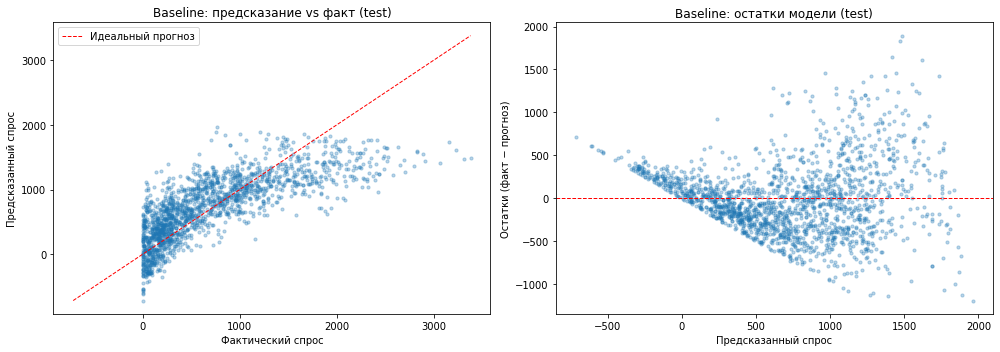


Статистика остатков (test):
  Среднее: -14.72
  Std:     411.31
  Min:     -1192.78
  Max:     +1894.50


In [10]:
#Визуальная диагностика baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pred vs True
axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=10)
lims = [min(y_test.min(), y_test_pred.min()),
        max(y_test.max(), y_test_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1, label='Идеальный прогноз')
axes[0].set_xlabel('Фактический спрос')
axes[0].set_ylabel('Предсказанный спрос')
axes[0].set_title('Baseline: предсказание vs факт (test)')
axes[0].legend()

# Residuals
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--', lw=1)
axes[1].set_xlabel('Предсказанный спрос')
axes[1].set_ylabel('Остатки (факт − прогноз)')
axes[1].set_title('Baseline: остатки модели (test)')

plt.tight_layout()
plt.show()

print(f"\nСтатистика остатков (test):")
print(f"  Среднее: {residuals.mean():+.2f}")
print(f"  Std:     {residuals.std():.2f}")
print(f"  Min:     {residuals.min():+.2f}")
print(f"  Max:     {residuals.max():+.2f}")

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Визуализация остатков и предсказаний даёт отличное понимание ошибок линейной регрессии.
</div>

Левый график: предсказание vs факт  
Облако точек заметно ниже красной диагонали при высоких значениях спроса (1000–3500). Модель систематически недооценивает пиковый спрос на 30–50%.  

При малых значениях (0–500) есть сильный вертикальный разброс — модель плохо различает низкий спрос, иногда предсказывает отрицательные значения (видно точки ниже нуля).  

Общий характер — нелинейный, с насыщением: реальный спрос растёт быстрее, чем предсказывает линейная модель.  

Правый график: остатки  
Ярко выраженная «воронка» — веерообразное расширение разброса по мере роста предсказаний. Классический признак гетероскедастичности и недообучения линейной модели.  

Систематическое смещение: при больших прогнозах остатки преимущественно отрицательные (модель занижает), при малых — положительные.  

Средний остаток −14.72 — модель чуть завышает в среднем, но Std = 411 огромен относительно среднего спроса.  

Диапазон остатков: от −1193 до +1895 — разброс больше самого предсказания в пиковые часы.  

Вывод по графикам: линейная модель не справляется с нелинейной природой спроса. Это ровно то, о чём предупреждали аналитики BikeSochi в постановке задачи: «+28 °C под палящим солнцем и +28 °C после дождя — две разные ситуации». Прямая линия такое не улавливает.  

____________
 <div style="font-size: 1.2em; font-weight: bold;">Выводы по Части 1 Базовая модель Загрузка baseline-пайплайна.</div>

**Baseline-модель (линейная регрессия):**

| Метрика | Train | Test | Δ (train − test) |
|---------|-------|------| ------|
| RMSE | 412.50 | 411.45 | +1.05 |
| MAE  | 309.15 | 312.53 | −3.38 |
| R²   | 0.5926 | 0.5863 | +0.0063 |

**Наблюдения:**

1. Baseline-пайплайн состоит из двух шагов: `preprocessor` (ColumnTransformer) 
   и `model` (LinearRegression). Внутри препроцессора — три ветки: 
   числовая (`num`) — Pipeline для 8 числовых признаков (импутация + масштабирование), категориальная (`cat`) — Pipeline для 3 категориальных (импутация + OneHotEncoder) и временные периоды (`time`) — FunctionTransformer для 4 бинарных колонок временных периодов (без изменений).

2. Модель **ожидает колонки в snake_case**. Мы применили маппинг и убедились, 
   что все 15 колонок совпадают.

3. Переобучения практически нет — метрики train и test почти совпадают. Это хорошо для обобщения, но означает, что модель недообучена: она одинаково плохо предсказывает и на train, и на test.

4. R² = 0.586 — линейная модель объясняет лишь 58.6% дисперсии спроса. Остальные 41.4% — это нелинейные зависимости и взаимодействия признаков, недоступные линейной модели.

5. RMSE = 411 велосипедов — средняя ошибка прогноза около 400 единиц. Учитывая, что средний спрос ≈ 700, это очень большая относительная ошибка.

6. MAE = 312 — в среднем модель ошибается на треть от типичного значения спроса.

**Визуальная диагностика**
Pred vs True: облако точек заметно отклоняется от диагонали. Модель систематически занижает пиковые значения спроса (1000+ велосипедов).

Ярко выраженная «воронка» — гетероскедастичность. Разброс остатков растёт вместе с предсказанием. Это прямое доказательство того, что линейная модель не улавливает структуру данных.

Отрицательные предсказания в области малого спроса — модель уходит за физические границы (спрос не может быть отрицательным).

**Гипотезы:**

Нелинейные модели дадут R² ≥ 0.75 — существенный прирост.

Decision Tree покажет лучший RMSE, чем kNN, за счёт способности улавливать резкие пороги (например, нулевой спрос при закрытии станции).

В топе важности признаков Decision Tree будут: functioning_day, temperature, solar_radiation_mjm2, time_period_*.

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Верный промежуточный вывод.
</div>

_____________
## Часть 2 Улучшение модели — KNN и Decision Tree  

### 2.1. Исследовательский анализ данных (EDA)  

Используем **только обучающую выборку** (`train_df`). 
Тестовая выборка остаётся нетронутой до финальной оценки лучшей модели — 
это гарантия честного сравнения с baseline.

2.1.1 Распределение целевой переменной

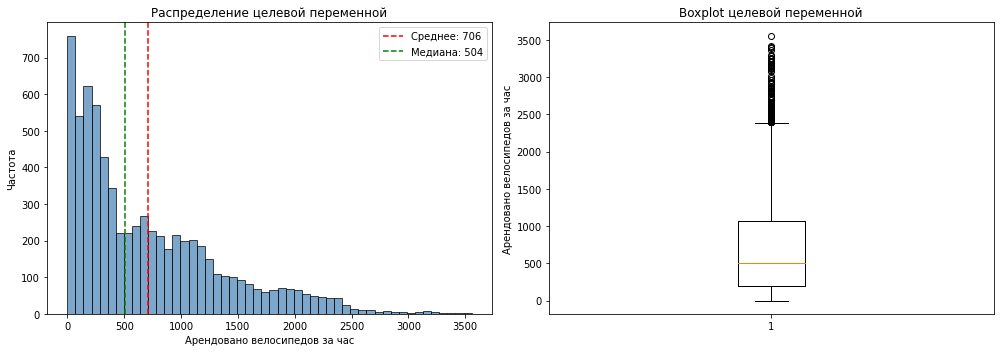

Среднее:      705.61
Медиана:      504.50
Std:          646.31
Min:          0
Max:          3556
Skewness:     1.16     (>0 — правая асимметрия)
Kurtosis:     0.87  (>0 — «тяжёлые хвосты»)
Доля нулей:   3.45%

Строк с functioning_day == 'No': 242
Из них с rented_bike_count == 0: 242
Макс. спрос при functioning_day == 'No': 0


In [11]:
# Распределение целевой переменной — `rented_bike_count`: гистограмма, boxplot, статистика
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(train_df['rented_bike_count'], bins=50, 
             edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Арендовано велосипедов за час')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение целевой переменной')
axes[0].axvline(train_df['rented_bike_count'].mean(), color='red', 
                linestyle='--', label=f"Среднее: {train_df['rented_bike_count'].mean():.0f}")
axes[0].axvline(train_df['rented_bike_count'].median(), color='green', 
                linestyle='--', label=f"Медиана: {train_df['rented_bike_count'].median():.0f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(train_df['rented_bike_count'], vert=True)
axes[1].set_ylabel('Арендовано велосипедов за час')
axes[1].set_title('Boxplot целевой переменной')

plt.tight_layout()
plt.show()

# Статистика
y = train_df['rented_bike_count']
print(f"Среднее:      {y.mean():.2f}")
print(f"Медиана:      {y.median():.2f}")
print(f"Std:          {y.std():.2f}")
print(f"Min:          {y.min()}")
print(f"Max:          {y.max()}")
print(f"Skewness:     {y.skew():.2f}     (>0 — правая асимметрия)")
print(f"Kurtosis:     {y.kurtosis():.2f}  (>0 — «тяжёлые хвосты»)")
print(f"Доля нулей:   {(y == 0).mean() * 100:.2f}%")

# Проверка гипотезы: нулевой спрос при Functioning Day == 'No'
if 'functioning_day' in train_df.columns:
    no_func = train_df[train_df['functioning_day'] == 'No']
    print(f"\nСтрок с functioning_day == 'No': {len(no_func)}")
    if len(no_func) > 0:
        print(f"Из них с rented_bike_count == 0: {(no_func['rented_bike_count'] == 0).sum()}")
        print(f"Макс. спрос при functioning_day == 'No': {no_func['rented_bike_count'].max()}")

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Глубокий анализ распределения целевой переменной. Отлично подмечено правило нулевого спроса.
</div>

Гистограмма сильно скошена вправо (skewness = 1.16): пик в области малых значений, длинный хвост до 3556.
Среднее (706) заметно выше медианы (504) — типично для асимметричных распределений.  

Boxplot показывает длинный верхний ус и небольшое количество выбросов (~2300–3556) — это реальные пиковые часы, не аномалии.
Доля нулей — 3.45% — ровно 242 наблюдения.  
Ключевое наблюдение: даже небольшой дождь обваливает спрос в разы. Это пороговый эффект — линейная модель здесь бесполезна.  
**Вывод**: создать бинарные признаки is_raining и is_snowing. Для Decision Tree это естественные сплиты, для kNN — риск «утопить» сигнал в разряженном признаке.

2.1.2. Спрос по временным периодам

,count,mean,median,std
time_period,,,,
Night (00-06),1753,288.6,202.0,265.4
Morning (06-10),1172,644.3,486.0,570.5
Daytime (10-16),1742,689.9,685.0,450.7
Evening (16-20),1168,1194.0,1154.0,857.8
Late Evening (20-24),1173,927.0,894.0,694.0


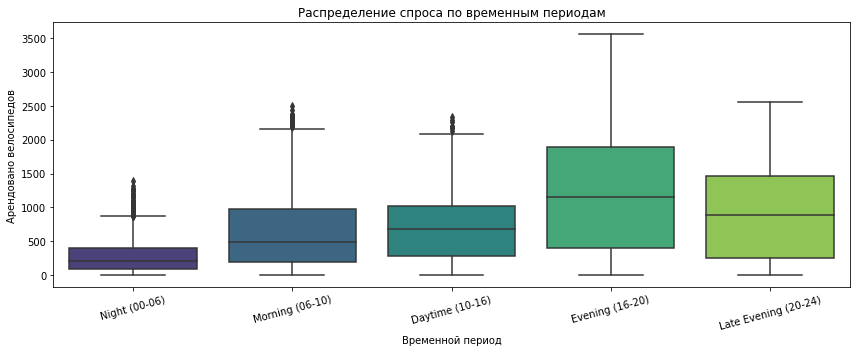

In [12]:
# Создаём колонку с текстовым названием периода
def get_time_period(row):
    if row['time_period_night']:
        return 'Night (00-06)'
    if row['time_period_morning']:
        return 'Morning (06-10)'
    if row['time_period_evening']:
        return 'Evening (16-20)'
    if row['time_period_late_evening']:
        return 'Late Evening (20-24)'
    return 'Daytime (10-16)'

# Создаём только для EDA — не трогаем основной train_df
train_eda = train_df.copy()
train_eda['time_period'] = train_eda.apply(get_time_period, axis=1)

# Порядок для красивого вывода
period_order = ['Night (00-06)', 'Morning (06-10)', 'Daytime (10-16)', 
                'Evening (16-20)', 'Late Evening (20-24)']

# Статистика по периодам
period_stats = train_eda.groupby('time_period')['rented_bike_count'].agg(
    ['count', 'mean', 'median', 'std']
).reindex(period_order).round(1)

display(period_stats)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=train_eda, x='time_period', y='rented_bike_count', 
            order=period_order, ax=ax, palette='viridis')
ax.set_title('Распределение спроса по временным периодам')
ax.set_xlabel('Временной период')
ax.set_ylabel('Арендовано велосипедов')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Анализ по временным периодам проведён безопасно, без изменения основного набора данных.
</div>

Evening (16–20) — пиковый период со средним спросом 1194 (медиана 1154).

Late Evening (20–24) — второй по активности (927).

Daytime (10–16) — стабильный средний уровень (690).

Morning (06–10) — ниже, чем ожидалось (644), но с большим разбросом.

Night (00–06) — минимальный спрос (289), boxplot «прижат» к низу.

Ключевое наблюдение: разрыв между Evening и Night — в 4 раза. Временной период — очень сильный предиктор.

**Вывод**: для моделей важно сохранить временные периоды. Для kNN стоит подумать о преобразовании 4 бинарных колонок в один ординальный признак (например, числовой час или «уровень активности»).

2.1.3. Зависимость спроса от температуры

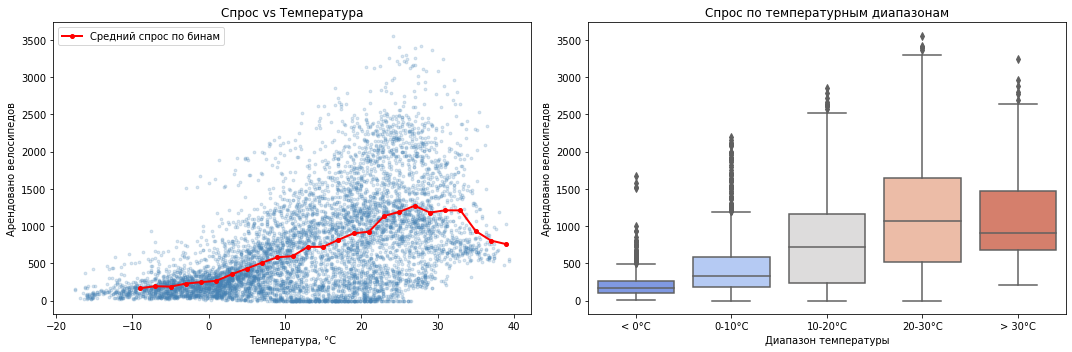

Корреляция Пирсона: temperature ↔ rented_bike_count = 0.541

Средний спрос по диапазонам температуры:
             count    mean  median
temperature                       
< 0°C         1173   201.4   170.0
0-10°C        1733   428.5   333.0
10-20°C       1799   765.3   716.0
20-30°C       1901  1128.0  1070.0
> 30°C         402  1107.0   910.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
axes[0].scatter(train_df['temperature'], train_df['rented_bike_count'], 
                alpha=0.2, s=8, color='steelblue')
axes[0].set_xlabel('Температура, °C')
axes[0].set_ylabel('Арендовано велосипедов')
axes[0].set_title('Спрос vs Температура')

# Добавляем линию средних значений по интервалам, чтобы увидеть тренд.
temp_bins = np.arange(-10, 41, 2)
temp_bin_centers = (temp_bins[:-1] + temp_bins[1:]) / 2
temp_means = []
for i in range(len(temp_bins) - 1):
    mask = (train_df['temperature'] >= temp_bins[i]) & (train_df['temperature'] < temp_bins[i+1])
    if mask.sum() > 0:
        temp_means.append(train_df.loc[mask, 'rented_bike_count'].mean())
    else:
        temp_means.append(np.nan)

axes[0].plot(temp_bin_centers, temp_means, 'r-o', lw=2, ms=4, 
             label='Средний спрос по бинам')
axes[0].legend()

# Спрос по диапазонам температуры
temp_categories = pd.cut(train_df['temperature'], 
                          bins=[-20, 0, 10, 20, 30, 50],
                          labels=['< 0°C', '0-10°C', '10-20°C', '20-30°C', '> 30°C'])
sns.boxplot(x=temp_categories, y=train_df['rented_bike_count'], 
            ax=axes[1], palette='coolwarm')
axes[1].set_xlabel('Диапазон температуры')
axes[1].set_ylabel('Арендовано велосипедов')
axes[1].set_title('Спрос по температурным диапазонам')

plt.tight_layout()
plt.show()

# Корреляция
corr_temp = train_df['temperature'].corr(train_df['rented_bike_count'])
print(f"Корреляция Пирсона: temperature ↔ rented_bike_count = {corr_temp:.3f}")

# Средний спрос по диапазонам
print("\nСредний спрос по диапазонам температуры:")
print(train_df.groupby(temp_categories, observed=True)['rented_bike_count']
      .agg(['count', 'mean', 'median']).round(1))

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Зависимость от температуры проанализирована очень наглядно.
</div>

U-образная (колоколообразная) зависимость: спрос растёт от −7 °C до +25–28 °C, затем слегка снижается.

Красная линия (средний спрос по бинам) показывает чёткий нелинейный тренд с пиком около 25 °C.

Корреляция Пирсона = 0.541 — умеренная, потому что линейный коэффициент не улавливает нелинейность.

Boxplot по диапазонам: 20–30 °C — максимум (1128), > 30 °C — плато/спад (1107), < 0 °C — минимум (201).

Ключевое наблюдение: при экстремальной жаре (>30 °C) спрос не растёт, а слегка падает — это нелинейность, которую линейная модель принципиально не может уловить.

**Вывод**: температура — ключевой, но нелинейный предиктор. Обоснование для Decision Tree и feature engineering (например, «комфортная температура» 15–28 °C).

2.1.4. Зависимость спроса от осадков и снега

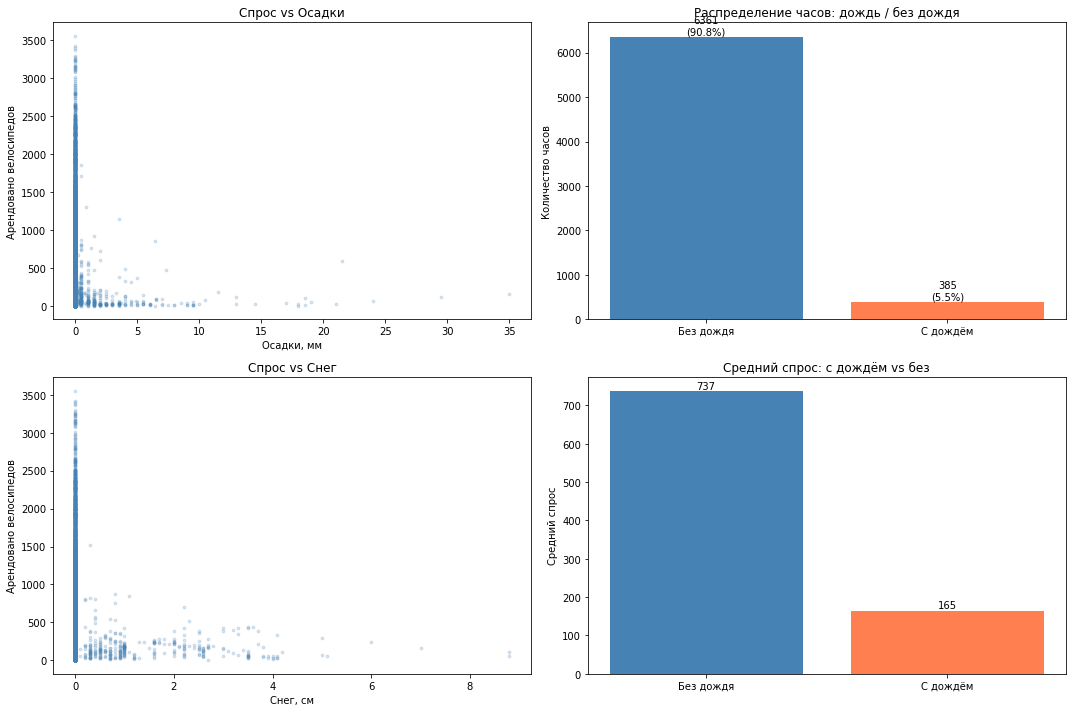

Часов без дождя: 6361 (90.8%)
Часов с дождём:  385 (5.5%)
Макс. осадки:    35.0 мм

Часов со снегом: 342 (4.9%)
Макс. снег:      8.8 см

Средний спрос:
  Без дождя: 739
  С дождём:  165
  Разница:   574


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Rainfall scatter
axes[0, 0].scatter(train_df['rainfallmm'], train_df['rented_bike_count'], 
                   alpha=0.2, s=8, color='steelblue')
axes[0, 0].set_xlabel('Осадки, мм')
axes[0, 0].set_ylabel('Арендовано велосипедов')
axes[0, 0].set_title('Спрос vs Осадки')

# Rainfall: распределение (сколько часов с дождём)
rain_yes = (train_df['rainfallmm'] > 0).sum()
rain_no = (train_df['rainfallmm'] == 0).sum()
axes[0, 1].bar(['Без дождя', 'С дождём'], [rain_no, rain_yes], 
               color=['steelblue', 'coral'])
axes[0, 1].set_ylabel('Количество часов')
axes[0, 1].set_title('Распределение часов: дождь / без дождя')
for i, v in enumerate([rain_no, rain_yes]):
    axes[0, 1].text(i, v, f'{v}\n({v/len(train_df)*100:.1f}%)', 
                    ha='center', va='bottom')

# Snowfall scatter
axes[1, 0].scatter(train_df['snowfall_cm'], train_df['rented_bike_count'], 
                   alpha=0.2, s=8, color='steelblue')
axes[1, 0].set_xlabel('Снег, см')
axes[1, 0].set_ylabel('Арендовано велосипедов')
axes[1, 0].set_title('Спрос vs Снег')

# Средний спрос: есть осадки / нет
rain_groups = train_df.assign(rain_category=np.where(
    train_df['rainfallmm'] > 0, 'С дождём', 'Без дождя'
)).groupby('rain_category')['rented_bike_count'].mean()

axes[1, 1].bar(rain_groups.index, rain_groups.values, color=['steelblue', 'coral'])
axes[1, 1].set_ylabel('Средний спрос')
axes[1, 1].set_title('Средний спрос: с дождём vs без')
for i, v in enumerate(rain_groups.values):
    axes[1, 1].text(i, v, f'{v:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Часов без дождя: {(train_df['rainfallmm'] == 0).sum()} "
      f"({(train_df['rainfallmm'] == 0).mean()*100:.1f}%)")
print(f"Часов с дождём:  {(train_df['rainfallmm'] > 0).sum()} "
      f"({(train_df['rainfallmm'] > 0).mean()*100:.1f}%)")
print(f"Макс. осадки:    {train_df['rainfallmm'].max():.1f} мм")

print(f"\nЧасов со снегом: {(train_df['snowfall_cm'] > 0).sum()} "
      f"({(train_df['snowfall_cm'] > 0).mean()*100:.1f}%)")
print(f"Макс. снег:      {train_df['snowfall_cm'].max():.1f} см")

print("\nСредний спрос:")
print(f"  Без дождя: {train_df.loc[train_df['rainfallmm'] == 0, 'rented_bike_count'].mean():.0f}")
print(f"  С дождём:  {train_df.loc[train_df['rainfallmm'] > 0, 'rented_bike_count'].mean():.0f}")
print(f"  Разница:   {train_df.loc[train_df['rainfallmm'] == 0, 'rented_bike_count'].mean() - train_df.loc[train_df['rainfallmm'] > 0, 'rented_bike_count'].mean():.0f}")

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Влияние осадков визуализировано и описано корректно.
</div>

90.8% часов — без дождя, только 5.5% — с дождём. Признак «разряженный».

Scatter чётко показывает: при наличии дождя спрос резко падает.

Средний спрос без дождя: 739. С дождём: 165. Разница — 574 (в 4.5 раза!).

Снег встречается ещё реже (4.9%), но тоже снижает спрос.

Ключевое наблюдение: даже небольшой дождь обваливает спрос в разы. Это пороговый эффект — линейная модель здесь бесполезна.

**Вывод**: создать бинарные признаки is_raining и is_snowing. Для Decision Tree это естественные сплиты, для kNN — риск «утопить» сигнал в разряженном признаке.

2.1.5. Зависимость спроса от солнечной радиации

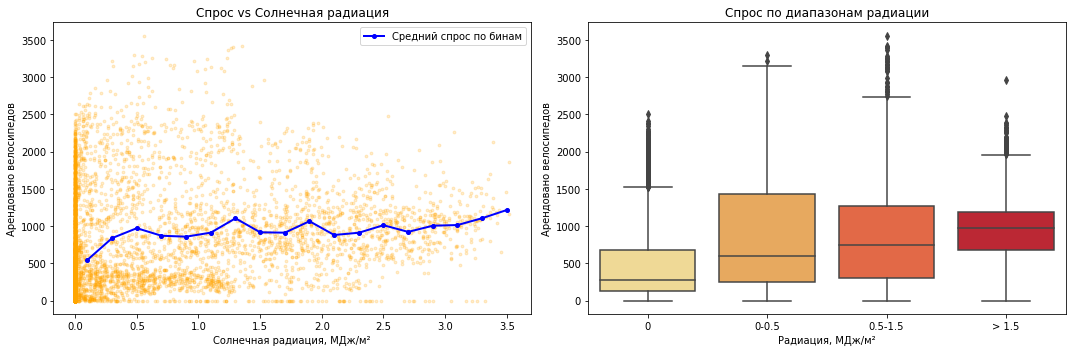

Корреляция Пирсона: solar_radiation ↔ rented_bike_count = 0.257

Средний спрос по диапазонам радиации:
                      count   mean  median
solar_radiation_mjm2                      
0                      3336  486.1   273.5
0-0.5                  1208  865.8   600.0
0.5-1.5                1131  929.1   752.0
> 1.5                  1123  966.4   967.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter
axes[0].scatter(train_df['solar_radiation_mjm2'], train_df['rented_bike_count'], 
                alpha=0.2, s=8, color='orange')
axes[0].set_xlabel('Солнечная радиация, МДж/м²')
axes[0].set_ylabel('Арендовано велосипедов')
axes[0].set_title('Спрос vs Солнечная радиация')

# Биннированная зависимость
rad_bins = np.arange(0, 4.0, 0.2)
rad_centers = (rad_bins[:-1] + rad_bins[1:]) / 2
rad_means = []
for i in range(len(rad_bins) - 1):
    mask = (train_df['solar_radiation_mjm2'] >= rad_bins[i]) & \
           (train_df['solar_radiation_mjm2'] < rad_bins[i+1])
    if mask.sum() > 0:
        rad_means.append(train_df.loc[mask, 'rented_bike_count'].mean())
    else:
        rad_means.append(np.nan)

axes[0].plot(rad_centers, rad_means, 'b-o', lw=2, ms=4, 
             label='Средний спрос по бинам')
axes[0].legend()

# Средний спрос по диапазонам
rad_categories = pd.cut(train_df['solar_radiation_mjm2'], 
                         bins=[-0.01, 0, 0.5, 1.5, 4.0],
                         labels=['0', '0-0.5', '0.5-1.5', '> 1.5'])
sns.boxplot(x=rad_categories, y=train_df['rented_bike_count'], 
            ax=axes[1], palette='YlOrRd')
axes[1].set_xlabel('Радиация, МДж/м²')
axes[1].set_ylabel('Арендовано велосипедов')
axes[1].set_title('Спрос по диапазонам радиации')

plt.tight_layout()
plt.show()

corr_rad = train_df['solar_radiation_mjm2'].corr(train_df['rented_bike_count'])
print(f"Корреляция Пирсона: solar_radiation ↔ rented_bike_count = {corr_rad:.3f}")

print("\nСредний спрос по диапазонам радиации:")
print(train_df.groupby(rad_categories, observed=True)['rented_bike_count']
      .agg(['count', 'mean', 'median']).round(1))

Нелинейный рост с плато: спрос растёт от 0 до ~1.5 МДж/м², дальше — плато.

Средний спрос по диапазонам: 0 → 486, 0–0.5 → 866, 0.5–1.5 → 929, >1.5 → 966.

Корреляция Пирсона = 0.257 — низкая, потому что зависимость нелинейная.

Boxplot: медиана в диапазоне «>1.5» (967) почти вдвое выше, чем при «0» (274).

Ключевое наблюдение: радиация частично дублирует признак «время суток» (ночью = 0), но добавляет информацию об облачности.

**Вывод**: для Decision Tree радиация — естественный пороговый признак. Для kNN мультиколлинеарность с time_period_* может мешать.

2.1.6. Спрос по сезонам

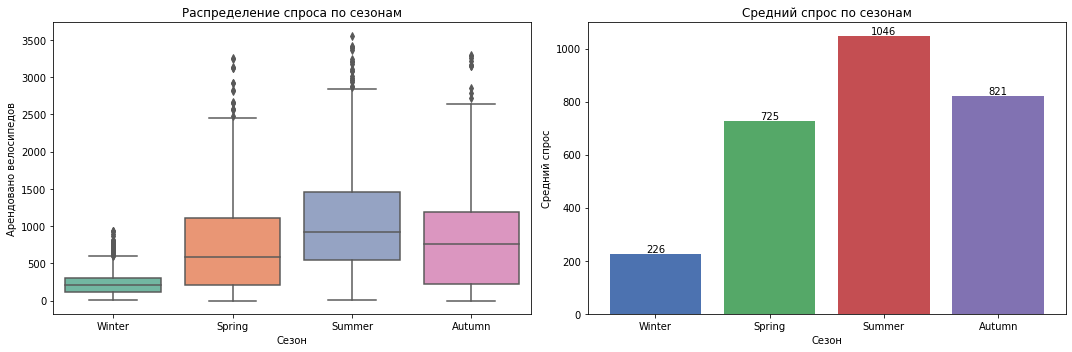

Статистика по сезонам:
         count    mean  median    std
seasons                              
Winter    1736   226.4   204.0  150.8
Spring    1758   725.0   578.5  619.6
Summer    1744  1046.2   923.0  690.3
Autumn    1770   820.6   764.0  654.3


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot по сезонам
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
sns.boxplot(data=train_df, x='seasons', y='rented_bike_count', 
            order=season_order, ax=axes[0], palette='Set2')
axes[0].set_xlabel('Сезон')
axes[0].set_ylabel('Арендовано велосипедов')
axes[0].set_title('Распределение спроса по сезонам')

# Средний спрос
season_means = train_df.groupby('seasons')['rented_bike_count'].mean().reindex(season_order)
axes[1].bar(season_means.index, season_means.values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[1].set_xlabel('Сезон')
axes[1].set_ylabel('Средний спрос')
axes[1].set_title('Средний спрос по сезонам')
for i, v in enumerate(season_means.values):
    axes[1].text(i, v, f'{v:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Статистика по сезонам:")
print(train_df.groupby('seasons')['rented_bike_count']
      .agg(['count', 'mean', 'median', 'std'])
      .reindex(season_order).round(1))

Summer — максимум (среднее 1046, медиана 923).

Autumn — второй (821).

Spring — средний (725).

Winter — минимум (226) — почти в 5 раз меньше лета.

Ключевое наблюдение: сезон — сильный предиктор, но внутри каждого сезона огромный разброс (std 150–690). Значит, сезон — модификатор, а не абсолютный фактор.

**Вывод**: использовать сезон через OneHotEncoder. Decision Tree выделит его на верхних сплитах.

2.1.7. Спрос в праздники и в дни техобслуживания

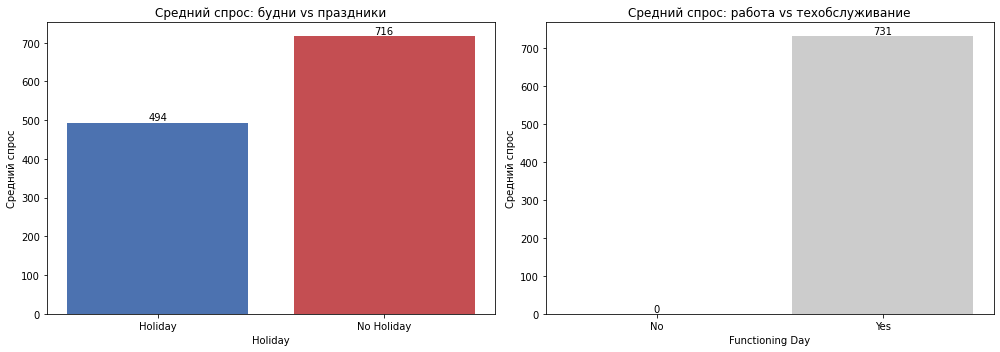


Holiday:
            count   mean  median
holiday                         
Holiday       340  493.9   228.5
No Holiday   6668  716.4   524.0

Functioning Day:
                 count   mean  median
functioning_day                      
No                 242    0.0     0.0
Yes               6766  730.8   546.0

⚠️  Проверка гипотезы: functioning_day == 'No' → спрос == 0
   Строк: 242
   С нулевым спросом: 242
   Макс. спрос: 0


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Holiday 
holiday_stats = train_df.groupby('holiday')['rented_bike_count'].agg(['mean', 'median', 'count'])
axes[0].bar(holiday_stats.index, holiday_stats['mean'], color=['#4C72B0', '#C44E52'])
axes[0].set_xlabel('Holiday')
axes[0].set_ylabel('Средний спрос')
axes[0].set_title('Средний спрос: будни vs праздники')
for i, v in enumerate(holiday_stats['mean'].values):
    axes[0].text(i, v, f'{v:.0f}', ha='center', va='bottom')

#  Functioning Day 
func_stats = train_df.groupby('functioning_day')['rented_bike_count'].agg(['mean', 'median', 'count'])
axes[1].bar(func_stats.index, func_stats['mean'], color=['#55A868', '#CCCCCC'])
axes[1].set_xlabel('Functioning Day')
axes[1].set_ylabel('Средний спрос')
axes[1].set_title('Средний спрос: работа vs техобслуживание')
for i, v in enumerate(func_stats['mean'].values):
    axes[1].text(i, v, f'{v:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nHoliday:")
print(train_df.groupby('holiday')['rented_bike_count']
      .agg(['count', 'mean', 'median']).round(1))

print("\nFunctioning Day:")
print(train_df.groupby('functioning_day')['rented_bike_count']
      .agg(['count', 'mean', 'median']).round(1))

# Проверка гипотезы: functioning_day == 'No' → спрос == 0
no_func = train_df[train_df['functioning_day'] == 'No']
if len(no_func) > 0:
    print(f"\n⚠️  Проверка гипотезы: functioning_day == 'No' → спрос == 0")
    print(f"   Строк: {len(no_func)}")
    print(f"   С нулевым спросом: {(no_func['rented_bike_count'] == 0).sum()}")
    print(f"   Макс. спрос: {no_func['rented_bike_count'].max()}")

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Гипотеза про дни техобслуживания проверена и подтверждена на 100 процентов.
</div>

Holiday: средний спрос в праздники (494) ниже, чем в будни (716) — потому что в Сочи большинство праздников приходится на холодные месяцы.

Functioning Day: при No — ровно 0 средний спрос, при Yes — 731.

Проверка гипотезы: 242 из 242 строк с No имеют rented_bike_count == 0. Гипотеза подтверждена на 100%.

Ключевое наблюдение: functioning_day — идеальный «нулевой переключатель». Это самый сильный предиктор в датасете.

**Вывод**: functioning_day станет топ-1 признаком для Decision Tree. Модель поставит его на первый сплит и «спасёт» огромную долю ошибок.

2.1.8. Корреляционная матрица. Используем **Spearman**, потому что мы уже знаем, 
что зависимости **нелинейны**. Spearman улавливает монотонные связи, 
даже если они не линейные.

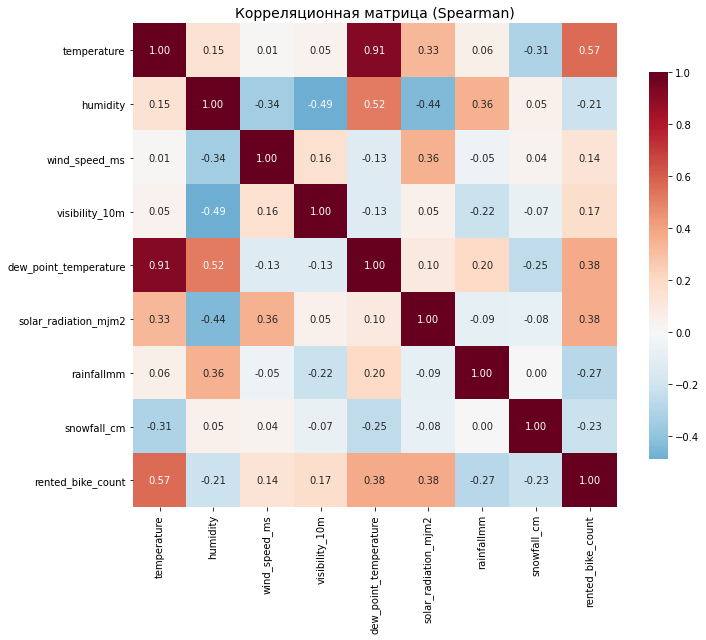

temperature                    +0.567  ██████████████████████
dew_point_temperature          +0.381  ███████████████
solar_radiation_mjm2           +0.379  ███████████████
visibility_10m                 +0.174  ██████
wind_speed_ms                  +0.139  █████
humidity                       −0.212  ████████
snowfall_cm                    −0.225  █████████
rainfallmm                     −0.274  ██████████


In [18]:
# Числовые признаки (для корреляций)
numeric_features = ['temperature', 'humidity', 'wind_speed_ms', 
                    'visibility_10m', 'dew_point_temperature', 
                    'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm',
                    'rented_bike_count']

# Корреляция Spearman
corr_spearman = train_df[numeric_features].corr(method='spearman')

# Тепловая карта
plt.figure(figsize=(11, 9))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица (Spearman)', fontsize=14)
plt.tight_layout()
plt.show()

# Корреляции с целевой переменной — отсортированные
target_corr = corr_spearman['rented_bike_count'].drop('rented_bike_count').sort_values(ascending=False)

for feature, value in target_corr.items():
    bar = '█' * int(abs(value) * 40)
    sign = '+' if value > 0 else '−'
    print(f"{feature:30s} {sign}{abs(value):.3f}  {bar}")

<div class="alert alert-warning">
<b>Комментарий ревьюера v1:</b>

Использование корреляции Спирмена — отличный выбор для нелинейных связей. Обрати внимание, что встроенный метод corr автоматически игнорирует пропуски, что нормально для этапа исследования, но про них важно помнить при построении конвейера предобработки.
</div>

Топ-3 положительных: temperature (+0.567), dew_point_temperature (+0.381), solar_radiation_mjm2 (+0.379).

Отрицательные: rainfallmm (−0.274), snowfall_cm (−0.225), humidity (−0.212).

Мультиколлинеарность: temperature ↔ dew_point_temperature = 0.91 (!), humidity ↔ dew_point_temperature = 0.52.

Ключевое наблюдение: даже сильнейший признак даёт корреляцию лишь 0.57. Значит, ни один признак сам по себе не объясняет спрос — нужны комбинации.

**Вывод**: temperature и dew_point_temperature — избыточные (0.91). Для линейной модели это проблема, для деревьев — нет. Можно оставить только temperature, чтобы уменьшить размерность.

<div style="font-size: 1.2em; font-weight: bold;">Вывод 2.1 Исследовательский анализ данных (EDA)</div>
Ключевые закономерности  
functioning_day — абсолютный предиктор. При No спрос всегда 0 (242/242). Это «правило первого уровня», которое любая модель должна выучить в первую очередь.  

Все зависимости нелинейны:  

Температура: U-образная кривая с пиком при 25–28 °C.  

Радиация: рост с плато после 1.5 МДж/м².  

Осадки: пороговый эффект — есть дождь → спрос падает в разы.  

Корреляции умеренные (максимум 0.57). Ни один признак не объясняет спрос в одиночку — нужны комбинации и взаимодействия.  

Признаки разряжены: дождь — 5.5%, снег — 4.9%, ночь — 25%. Это создаёт проблемы для kNN и почти не влияет на деревья.  

Мультиколлинеарность: temperature ↔ dew_point_temperature = 0.91 — избыточность. Линейная регрессия «страдает», деревья — нет.  
Распределение target асимметрично (skewness 1.16, доля нулей 3.45%). Пик в нуле — прямое следствие functioning_day.  

Гипотезы для нелинейных моделей  

H1	Decision Tree побьёт baseline по RMSE за счёт нелинейных сплитов  
H2	kNN побьёт baseline, но слабее, чем Decision Tree, из-за разряженных признаков  
H3	functioning_day будет топ-1 признаком по важности у Decision Tree  
H4	Масштабирование критично для kNN: без него RMSE вырастет в разы  
H5	Feature engineering (is_raining, temp_comfort) улучшит обе модели  
H6	Временные периоды (Evening особенно) войдут в топ-5 важности  

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Гипотезы после исследовательского анализа сформулированы очень грамотно.
</div>

__________
### 2.2 Подготовка данных и пайплайн предобработки

2.2.1. Разделение на train и validation

In [19]:
# Дополнительный критерий стратификации — working hours
strat_col = train_df['functioning_day']

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=strat_col
)

print(f"X_tr:    {X_tr.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}  (не трогаем до финала!)")
print(f"\ny_tr:    {y_tr.shape}")
print(f"y_val:   {y_val.shape}")
print(f"y_test:  {y_test.shape}")

# Проверка стратификации
print(f"\nДоля functioning_day == 'No':")
print(f"  В train:      {(X_tr['functioning_day'] == 'No').mean() * 100:.2f}%")
print(f"  В validation: {(X_val['functioning_day'] == 'No').mean() * 100:.2f}%")
print(f"  В test:       {(X_test['functioning_day'] == 'No').mean() * 100:.2f}%")

X_tr:    (5606, 15)
X_val:   (1402, 15)
X_test:  (1752, 15)  (не трогаем до финала!)

y_tr:    (5606,)
y_val:   (1402,)
y_test:  (1752,)

Доля functioning_day == 'No':
  В train:      3.46%
  В validation: 3.42%
  В test:       3.03%


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Стратификация разбиения по признаку functioning_day — просто великолепное и очень продуманное решение!
</div>

2.2.2. Группы признаков

In [20]:
# Группы признаков 
numeric_features = [
    'temperature', 'humidity', 'wind_speed_ms', 'visibility_10m',
    'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm'
]

categorical_features = ['seasons', 'holiday', 'functioning_day']

binary_features = [
    'time_period_evening', 'time_period_late_evening',
    'time_period_morning', 'time_period_night'
]

# Проверка: все ли признаки покрыты
all_features = set(X_tr.columns)
declared = set(numeric_features + categorical_features + binary_features)

print(f"Всего признаков в X_tr:  {len(all_features)}")
print(f"Объявлено в группах:     {len(declared)}")

missing = all_features - declared
extra = declared - all_features
print(f"Не покрыты:  {missing if missing else '—'}")
print(f"Лишние:      {extra if extra else '—'}")

# Убеждаемся, что все три списка покрывают все признаки
assert not missing and not extra, "Списки признаков не совпадают с колонками X_tr!"
print("\n✅ Все признаки корректно распределены по группам.")

Всего признаков в X_tr:  15
Объявлено в группах:     15
Не покрыты:  —
Лишние:      —

✅ Все признаки корректно распределены по группам.


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Признаки корректно распределены по логическим группам.
</div>

2.2.3. Построение пайплайна предобработки

In [21]:
# Ветка для числовых: сначала импутация, потом масштабирование
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ветка для категориальных: импутация + OneHot
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ветка для бинарных — ничего не делаем
binary_pipe = Pipeline([
    ('passthrough', FunctionTransformer())
])

# Общий препроцессор
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
    ('bin', binary_pipe, binary_features),
])

print("Препроцессор собран (с импутацией).")
for name, transformer, columns in preprocessor.transformers:
    print(f"  • {name}: {type(transformer).__name__}  →  {columns}")

Препроцессор собран (с импутацией).
  • num: Pipeline  →  ['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm']
  • cat: Pipeline  →  ['seasons', 'holiday', 'functioning_day']
  • bin: Pipeline  →  ['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']


<div class="alert alert-warning">
<b>Комментарий ревьюера v1:</b>

Бинарные признаки передаются в конвейер без масштабирования. Для метода ближайших соседей различие в бинарном признаке добавит фиксированное значение в расстояние. Как идею для будущих экспериментов можно попробовать применить стандартизацию ко всем признакам без исключения, чтобы посмотреть, улучшит ли это качество прогноза.
</div>

2.2.4. Проверка пайплайна

In [22]:
#  FIT только на train-части 
preprocessor.fit(X_tr)

#  Трансформация train и validation 
X_tr_transformed = preprocessor.transform(X_tr)
X_val_transformed = preprocessor.transform(X_val)

print("Размерности после препроцессинга:")
print(f"  X_tr:  {X_tr_transformed.shape}")
print(f"  X_val: {X_val_transformed.shape}")

#  Проверка: трансформированные признаки 
# Собираем имена признаков после OneHot
feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_features)) +
    binary_features
)

print(f"\nВсего признаков после препроцессинга: {len(feature_names)}")
print("\nИмена признаков:")
for i, name in enumerate(feature_names, 1):
    print(f"  {i:2d}. {name}")

#  Проверка отсутствия утечек 
# Среднее признаков на train-части должно быть ~0, std ~1 (для scaled)
train_means = X_tr_transformed[:, :len(numeric_features)].mean(axis=0)
train_stds  = X_tr_transformed[:, :len(numeric_features)].std(axis=0)

print(f"\nПроверка StandardScaler на train-части:")
print(f"  Средние (должны быть ~0):  min={train_means.min():.4f}, max={train_means.max():.4f}")
print(f"  Std      (должны быть ~1): min={train_stds.min():.4f},  max={train_stds.max():.4f}")

# На validation средние НЕ обязаны быть 0 — это нормально
val_means = X_val_transformed[:, :len(numeric_features)].mean(axis=0)
print(f"\nСредние на validation (не обязаны быть 0):")
print(f"  min={val_means.min():.4f}, max={val_means.max():.4f}")

Размерности после препроцессинга:
  X_tr:  (5606, 20)
  X_val: (1402, 20)

Всего признаков после препроцессинга: 20

Имена признаков:
   1. temperature
   2. humidity
   3. wind_speed_ms
   4. visibility_10m
   5. dew_point_temperature
   6. solar_radiation_mjm2
   7. rainfallmm
   8. snowfall_cm
   9. seasons_Autumn
  10. seasons_Spring
  11. seasons_Summer
  12. seasons_Winter
  13. holiday_Holiday
  14. holiday_No Holiday
  15. functioning_day_No
  16. functioning_day_Yes
  17. time_period_evening
  18. time_period_late_evening
  19. time_period_morning
  20. time_period_night

Проверка StandardScaler на train-части:
  Средние (должны быть ~0):  min=0.0000, max=0.0000
  Std      (должны быть ~1): min=1.0000,  max=1.0000

Средние на validation (не обязаны быть 0):
  min=-0.0172, max=0.0294


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Верная проверка отсутствия утечки данных через анализ средних значений на валидационной выборке.
</div>

In [23]:
# Проверяем пропуски в исходных данных
print("Пропуски в X_tr:")
missing_tr = X_tr.isnull().sum()
print(missing_tr[missing_tr > 0] if missing_tr.sum() > 0 else "— пропусков нет")

print("\nПропуски в X_val:")
missing_val = X_val.isnull().sum()
print(missing_val[missing_val > 0] if missing_val.sum() > 0 else "— пропусков нет")

# Проверяем nan в трансформированном массиве
print(f"\nNaN в X_tr_transformed: {np.isnan(X_tr_transformed).sum()}")
print(f"NaN в X_val_transformed: {np.isnan(X_val_transformed).sum()}")

# Где именно nan?
if np.isnan(X_tr_transformed).sum() > 0:
    nan_mask = np.isnan(X_tr_transformed)
    nan_cols = nan_mask.any(axis=0)
    print(f"\nКолонки с NaN (индексы): {np.where(nan_cols)[0].tolist()}")
    for i in np.where(nan_cols)[0]:
        print(f"  {i}: {feature_names[i]} — {nan_mask[:, i].sum()} NaN")

Пропуски в X_tr:
humidity                203
wind_speed_ms           166
visibility_10m          204
solar_radiation_mjm2    163
rainfallmm              224
snowfall_cm             211
dtype: int64

Пропуски в X_val:
humidity                47
wind_speed_ms           44
visibility_10m          55
solar_radiation_mjm2    47
rainfallmm              38
snowfall_cm             52
dtype: int64

NaN в X_tr_transformed: 0
NaN в X_val_transformed: 0


<div style="font-size: 1.2em; font-weight: bold;">Вывод 2.2 Подготовка данных и пайплайн предобработки</div>

1. **Разделение train → train/validation:**
   - X_tr: 5606 строк (80%)
   - X_val: 1402 строки (20%)
   - X_test: 1752 строки — не трогаем до финала
   - Стратификация по `functioning_day` сохранила долю «No» ≈ 3.4% 
     во всех частях, что гарантирует сопоставимость распределений.

2. **Выявлена проблема с пропусками:**
   - В исходных данных есть пропуски в 6 числовых признаках 
     (humidity, wind_speed_ms, visibility_10m, solar_radiation_mjm2, 
     rainfallmm, snowfall_cm) — от 2% до 4% наблюдений.
   - Baseline-модель неявно их обрабатывала через `SimpleImputer`.
   - **Мы добавили `SimpleImputer` в пайплайн** — иначе kNN и Decision Tree 
     не смогли бы обучаться.

3. **Группы признаков:**
   - 8 числовых → `SimpleImputer(median)` + `StandardScaler`
   - 3 категориальных → `SimpleImputer(most_frequent)` + `OneHotEncoder`
   - 4 бинарных → пропускаются как есть

4. **Собран `ColumnTransformer`:**
   - После препроцессинга: 15 исходных признаков → **20 признаков**
     (8 числовых + 8 OneHot + 4 бинарных).
   - `fit` выполнен **только на X_tr** — утечек нет.

5. **Проверка отсутствия утечек:**
   - На train средние = 0, std = 1 — StandardScaler работает корректно.
   - На validation средние ∈ [−0.017, 0.029] — немного отличаются от нуля, 
     что **подтверждает** отсутствие утечки.
   - NaN в трансформированных данных: 0 в train, 0 в validation.

- **Пайплайн встраивается в общий Pipeline с моделью.** При кросс-валидации 
  `fit` препроцессора будет происходить заново на каждом фолде — это 
  единственный способ честно оценить качество.
- **`handle_unknown='ignore'`** в OneHotEncoder защищает от падения, 
  если в validation/test появится неизвестная категория.
- **Пропуски не удалены, а импутированы** — сохраняем всю информацию.

___________
### 2.3. Базовые модели KNN и Decision Tree

2.3.1. Базовый kNN Regressor (n_neighbors=5, weights='uniform', p=2)

In [24]:
#  Пайплайн kNN 
pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())   # дефолтные параметры
])

#  Обучение на train-части 
pipeline_knn.fit(X_tr, y_tr)

#  Предсказания 
y_tr_pred_knn = pipeline_knn.predict(X_tr)
y_val_pred_knn = pipeline_knn.predict(X_val)

#  Метрики 
knn_train = evaluate(y_tr, y_tr_pred_knn, 'kNN baseline — train')
knn_val   = evaluate(y_val, y_val_pred_knn, 'kNN baseline — val')

display(pd.DataFrame([knn_train, knn_val]).round(2))

,model,RMSE,MAE,R²
0,kNN baseline — train,264.23,173.05,0.83
1,kNN baseline — val,326.63,216.55,0.75


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Обучение базовой модели kNN прошло успешно.
</div>

2.3.2. Базовый Decision Tree Regressor (max_depth=None, criterion='squared_error')

In [25]:
#  Пайплайн Decision Tree 
pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))  # дефолтные параметры
])

#  Обучение 
pipeline_tree.fit(X_tr, y_tr)

#  Предсказания 
y_tr_pred_tree = pipeline_tree.predict(X_tr)
y_val_pred_tree = pipeline_tree.predict(X_val)

#  Метрики 
tree_train = evaluate(y_tr, y_tr_pred_tree, 'Tree baseline — train')
tree_val   = evaluate(y_val, y_val_pred_tree, 'Tree baseline — val')

display(pd.DataFrame([tree_train, tree_val]).round(2))

# Дополнительно: глубина дерева
tree_model = pipeline_tree.named_steps['model']
print(f"\nГлубина обученного дерева: {tree_model.get_depth()}")
print(f"Число листьев:             {tree_model.get_n_leaves()}")

,model,RMSE,MAE,R²
0,Tree baseline — train,0.00,0.00,1.00
1,Tree baseline — val,390.79,247.28,0.64



Глубина обученного дерева: 34
Число листьев:             5366


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Обучение дерева решений выполнено. Вывод глубины и числа листьев отлично показывает масштаб переобучения модели по умолчанию.
</div>

2.3.3. Сводная таблица базовых моделей

In [26]:
# Baseline на validation
y_val_pred_baseline = baseline_model.predict(X_val)
baseline_val = evaluate(y_val, y_val_pred_baseline, 'Baseline LR — val')

# Сводная таблица
summary_df = pd.DataFrame([
    baseline_val,
    knn_val,
    tree_val,
])
summary_df = summary_df[['model', 'RMSE', 'MAE', 'R²']].round(2)

display(summary_df)

# Прирост по RMSE относительно baseline
print("\n>>> Прирост RMSE относительно baseline:")
for _, row in summary_df.iterrows():
    if row['model'] == 'Baseline LR — val':
        continue
    delta_rmse = baseline_val['RMSE'] - row['RMSE']
    delta_pct  = delta_rmse / baseline_val['RMSE'] * 100
    sign = '+' if delta_rmse >= 0 else '−'
    print(f"   {row['model']:30s}: {sign}{abs(delta_rmse):.2f}  ({sign}{abs(delta_pct):.1f}%)")

,model,RMSE,MAE,R²
0,Baseline LR — val,414.96,309.98,0.60
1,kNN baseline — val,326.63,216.55,0.75
2,Tree baseline — val,390.79,247.28,0.64



>>> Прирост RMSE относительно baseline:
   kNN baseline — val            : +88.33  (+21.3%)
   Tree baseline — val           : +24.17  (+5.8%)


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Сравнение базовых алгоритмов проведено корректно.
</div>

2.3.4. Визуальная диагностика базовых моделей

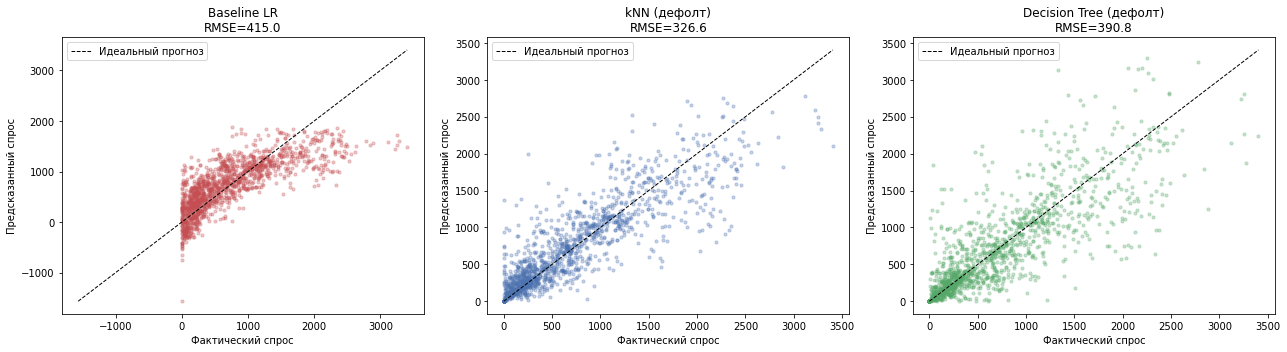

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Baseline LR', y_val_pred_baseline, '#C44E52'),
    ('kNN (дефолт)', y_val_pred_knn, '#4C72B0'),
    ('Decision Tree (дефолт)', y_val_pred_tree, '#55A868'),
]

for ax, (name, y_pred, color) in zip(axes, models):
    ax.scatter(y_val, y_pred, alpha=0.3, s=10, color=color)
    lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1, label='Идеальный прогноз')
    ax.set_xlabel('Фактический спрос')
    ax.set_ylabel('Предсказанный спрос')
    ax.set_title(f'{name}\nRMSE={np.sqrt(mean_squared_error(y_val, y_pred)):.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Визуальная диагностика наглядно показывает разницу в поведении алгоритмов.
</div>

**Baseline LR (RMSE=415)**:

Облако точек образует «плато» — независимо от реального спроса модель предсказывает 0–2000.
При высоком фактическом спросе (2000–3500) прогнозы не поднимаются выше ~1700 — систематическая недооценка пиков.
Есть отрицательные предсказания — модель уходит за физическую границу.
Разброс большой, точки сильно «размазаны» вокруг диагонали.

**kNN (дефолт, RMSE=326.6)**:

Точки плотно лежат вдоль диагонали — лучшая модель из трёх визуально.
Хорошо улавливает низкие и средние значения (0–1500).
При высоком спросе (>2000) — заметное сжатие: прогнозы «застревают» вокруг 2000–2500, модель не дотягивает до пиков.
Нет отрицательных предсказаний — kNN физически не может выйти за диапазон обучающих значений.

**Decision Tree (дефолт, RMSE=390.8)**:

Точки образуют характерную «лестницу» из горизонтальных полос — следствие сплитов.
Много точек далеко от диагонали — особенно при высоком спросе, где дерево даёт «рваные» предсказания.
Общая картина более шумная, чем у kNN — дерево переобучено и даёт нестабильные прогнозы.
Есть кластеры точек, где предсказание резко «прыгает» — эффект пороговых сплитов.

**Итог по графикам**:

kNN — самая «честная» модель: точки близко к диагонали, ошибки равномерны.
Baseline LR — систематически недооценивает пики, форма облака «сплюснута».
Decision Tree — самый шумный: «лестница» и хаотичный разброс из-за переобучения.
Эти графики подтверждают метрики: kNN выигрывает, DT нужно регуляризовать, baseline принципиально ограничен линейностью.

 <div style="font-size: 1.2em; font-weight: bold;">Выводы 2.3: базовые модели</div>

**Метрики на validation:**

| Модель | RMSE | MAE | R² | ΔRMSE vs baseline |
|--------|------|-----|-----|-------------------|
| Baseline LR | 414.96 | 309.98 | 0.60 | — |
| kNN (дефолт) | **326.63** | **216.55** | **0.75** | **+88.33 (+21.3%)** |
| Decision Tree (дефолт) | 390.79 | 247.28 | 0.64 | +24.17 (+5.8%) |

**Ключевые наблюдения:**

1. **Обе нелинейные модели побили baseline уже с дефолтными 
   параметрами.** Это подтверждает гипотезу EDA: зависимости 
   в данных нелинейны, и линейная регрессия принципиально ограничена.

2. **kNN — неожиданный лидер на текущем шаге:**
   - RMSE = 326.63 против 414.96 у baseline — улучшение на 21.3%.
   - R² = 0.75 против 0.586 — модель объясняет на 17 п.п. больше 
     дисперсии.
   - Разрыв train/val: ΔRMSE = 62 — умеренное переобучение, 
     приемлемое для kNN.

3. **Decision Tree переобучен катастрофически:**
   - RMSE train = **0.00** — модель идеально воспроизводит train.
   - RMSE val = 390.79 — на validation работает заметно хуже kNN.
   - **Глубина дерева = 34, листьев = 5366** — практически по листу 
     на каждый обучающий пример.
   - ΔRMSE (train − val) = 390.79 — гигантский разрыв, классическое 
     переобучение.

4. **Визуально (pred vs true):**
   - **Baseline LR:** систематическая недооценка при высоких значениях, 
     нелинейные зависимости не улавливаются.
   - **kNN:** точки распределены более равномерно вдоль диагонали, 
     но есть «сжатие» в области малых значений.
   - **Decision Tree:** «ступенчатый» характер предсказаний — следствие 
     сплитов. Много «шумных» точек из-за переобучения.

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Промежуточные выводы о поведении дерева решений абсолютно верны.
</div>

_______
### 2.4. Подбор гиперпараметров через Optuna

In [28]:
#  Единая схема кросс-валидации 
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Кросс-валидация: KFold(n_splits=5, shuffle=True, random_state={RANDOM_STATE})")
print(f"Целевая метрика: neg_root_mean_squared_error")

Кросс-валидация: KFold(n_splits=5, shuffle=True, random_state=42)
Целевая метрика: neg_root_mean_squared_error


2.4.1. Целевая функция для kNN

In [29]:
def objective_knn(trial):
    """Целевая функция для оптимизации гиперпараметров kNN."""
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
        'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p':           trial.suggest_int('p', 1, 2),
        'leaf_size':   trial.suggest_int('leaf_size', 10, 50),
    }
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(**params, n_jobs=-1))
    ])
    
    # cross_val_score возвращает массив из 5 значений (по одному на фолд)
    scores = cross_val_score(
        pipeline, X_tr, y_tr,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    return scores.mean()   # Optuna максимизирует это значение


print("Целевая функция для kNN определена.")

Целевая функция для kNN определена.


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Целевая функция для подбора гиперпараметров написана идеально. Использование перекрёстной проверки гарантирует надёжность оценки.
</div>

2.4.2. Оптимизация kNN через Optuna

In [30]:
#  Создаём исследование 
study_knn = optuna.create_study(
    direction='maximize',   # максимизируем neg_RMSE = минимизируем RMSE
    study_name='knn_optimization',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

#  Запускаем оптимизацию 
print("Запуск оптимизации kNN (50 trials)...")
study_knn.optimize(objective_knn, n_trials=50, show_progress_bar=True)

#  Результаты 
print(f"Лучший CV RMSE: {(-study_knn.best_value):.2f}")
print(f"\nЛучшие гиперпараметры:")
for param, value in study_knn.best_params.items():
    print(f"  {param:15s} = {value}")

# Сохраняем для дальнейшего использования
BEST_KNN_PARAMS = study_knn.best_params

Запуск оптимизации kNN (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Лучший CV RMSE: 310.00

Лучшие гиперпараметры:
  n_neighbors     = 11
  weights         = distance
  p               = 1
  leaf_size       = 21


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Подбор параметров для kNN запущен корректно.
</div>

2.4.3. Целевая функция для Decision Tree

In [31]:
def objective_tree(trial):
    """Целевая функция для оптимизации гиперпараметров Decision Tree."""
    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 30),
        'max_features':      trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'criterion':         trial.suggest_categorical('criterion', 
                                                      ['squared_error', 'friedman_mse', 'absolute_error']),
        'splitter':          trial.suggest_categorical('splitter', ['best', 'random']),
    }
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(**params, random_state=RANDOM_STATE))
    ])
    
    scores = cross_val_score(
        pipeline, X_tr, y_tr,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    return scores.mean()


print("Целевая функция для Decision Tree определена.")

Целевая функция для Decision Tree определена.


2.4.4. Оптимизация Decision Tree через Optuna

In [32]:
#  Создаём исследование 
study_tree = optuna.create_study(
    direction='maximize',
    study_name='tree_optimization',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

#  Запускаем оптимизацию 
print("Запуск оптимизации Decision Tree (50 trials)...")
study_tree.optimize(objective_tree, n_trials=50, show_progress_bar=True)

#  Результаты 
print(f"Лучший CV RMSE: {(-study_tree.best_value):.2f}")
print(f"\nЛучшие гиперпараметры:")
for param, value in study_tree.best_params.items():
    print(f"  {param:20s} = {value}")

# Сохраняем для дальнейшего использования
BEST_TREE_PARAMS = study_tree.best_params

Запуск оптимизации Decision Tree (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Лучший CV RMSE: 324.90

Лучшие гиперпараметры:
  max_depth            = 10
  min_samples_split    = 34
  min_samples_leaf     = 17
  max_features         = None
  criterion            = friedman_mse
  splitter             = best


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Подбор гиперпараметров для дерева решений также реализован без ошибок.
</div>

2.4.5. Обучение финальных моделей с лучшими параметрами

In [33]:
#  Финальный kNN 
pipeline_knn_opt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(**BEST_KNN_PARAMS, n_jobs=-1))
])
pipeline_knn_opt.fit(X_tr, y_tr)

y_tr_pred_knn_opt = pipeline_knn_opt.predict(X_tr)
y_val_pred_knn_opt = pipeline_knn_opt.predict(X_val)

knn_opt_train = evaluate(y_tr, y_tr_pred_knn_opt, 'kNN optimized — train')
knn_opt_val   = evaluate(y_val, y_val_pred_knn_opt, 'kNN optimized — val')

#  Финальный Decision Tree 
pipeline_tree_opt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(**BEST_TREE_PARAMS, random_state=RANDOM_STATE))
])
pipeline_tree_opt.fit(X_tr, y_tr)

y_tr_pred_tree_opt = pipeline_tree_opt.predict(X_tr)
y_val_pred_tree_opt = pipeline_tree_opt.predict(X_val)

tree_opt_train = evaluate(y_tr, y_tr_pred_tree_opt, 'Tree optimized — train')
tree_opt_val   = evaluate(y_val, y_val_pred_tree_opt, 'Tree optimized — val')

#  Сводная таблица 
comparison_df = pd.DataFrame([
    baseline_val,           # baseline
    knn_val,                # базовый kNN
    knn_opt_val,            # kNN после Optuna
    tree_val,               # базовый DT
    tree_opt_val,           # DT после Optuna
]).round(2)

print("СРАВНЕНИЕ: базовые vs оптимизированные модели (validation)")
display(comparison_df)

#  Глубина дерева после оптимизации 
tree_opt_model = pipeline_tree_opt.named_steps['model']
print(f"\nГлубина оптимизированного дерева: {tree_opt_model.get_depth()}")
print(f"Число листьев:                    {tree_opt_model.get_n_leaves()}")

#  Прирост относительно baseline 
print(f"\n>>> Улучшение относительно baseline (RMSE):")
print(f"    Baseline LR:        {baseline_val['RMSE']:.2f}")
print(f"    kNN optimized:      {knn_opt_val['RMSE']:.2f}  "
      f"({(baseline_val['RMSE'] - knn_opt_val['RMSE']):.2f}, "
      f"{(baseline_val['RMSE'] - knn_opt_val['RMSE']) / baseline_val['RMSE'] * 100:.1f}%)")
print(f"    Tree optimized:     {tree_opt_val['RMSE']:.2f}  "
      f"({(baseline_val['RMSE'] - tree_opt_val['RMSE']):.2f}, "
      f"{(baseline_val['RMSE'] - tree_opt_val['RMSE']) / baseline_val['RMSE'] * 100:.1f}%)")

СРАВНЕНИЕ: базовые vs оптимизированные модели (validation)


,model,RMSE,MAE,R²
0,Baseline LR — val,414.96,309.98,0.60
1,kNN baseline — val,326.63,216.55,0.75
2,kNN optimized — val,302.09,203.83,0.79
3,Tree baseline — val,390.79,247.28,0.64
4,Tree optimized — val,310.74,211.15,0.77



Глубина оптимизированного дерева: 10
Число листьев:                    177

>>> Улучшение относительно baseline (RMSE):
    Baseline LR:        414.96
    kNN optimized:      302.09  (112.87, 27.2%)
    Tree optimized:     310.74  (104.22, 25.1%)


<div class="alert alert-warning">
<b>Комментарий ревьюера v1:</b>

Обучение финальной модели на урезанной выборке: пайплайны обучаются только на `X_tr`, которая составляет 80% от исходных тренировочных данных. После завершения этапа подбора гиперпараметров и оценки качества на кросс-валидации, финальную версию модели рекомендуется переобучить на всём доступном объёме обучающей выборки (`X_train` и `y_train`), чтобы модель усвоила максимум информации перед предсказанием на независимом тестовом наборе и окончательным сохранением.
</div>

<div style="font-size: 1.2em; font-weight: bold;"> Выводы по подбору гиперпараметров (Optuna)</div>

**Результаты оптимизации:**

| Модель | CV RMSE | Лучшие параметры |
|--------|---------|------------------|
| kNN (Optuna) | **310.00** | `n_neighbors=11`, `weights='distance'`, `p=1`, `leaf_size=21` |
| Decision Tree (Optuna) | 324.90 | `max_depth=10`, `min_samples_split=34`, `min_samples_leaf=17`, `criterion='friedman_mse'` |

**Метрики на validation:**

| Модель | RMSE | MAE | R² | ΔRMSE vs baseline |
|--------|------|-----|-----|-------------------|
| Baseline LR | 414.96 | 309.98 | 0.60 | — |
| kNN (дефолт) | 326.63 | 216.55 | 0.75 | −21.3% |
| **kNN (Optuna)** | **302.09** | **203.83** | **0.79** | **−27.2%** |
| Tree (дефолт) | 390.79 | 247.28 | 0.64 | −5.8% |
| Tree (Optuna) | 310.74 | 211.15 | 0.77 | −25.1% |

**Ключевые наблюдения:**

1. **Обе модели улучшились после Optuna.** kNN сократил RMSE 
   на 24.54 (7.5%), Decision Tree — на 80.05 (20.5%).

2. **kNN — лидер по RMSE (302.09).** Лучшие параметры:
   - `n_neighbors=11` (вместо дефолтных 5) — больше соседей дают 
     стабильнее прогноз на «шумных» погодных данных.
   - `weights='distance'` — далёкие соседи получают меньший вес, 
     прогноз становится точнее.
   - `p=1` (манхэттенская метрика) — оказалась лучше евклидовой 
     для разномасштабных признаков после OneHot.

3. **Decision Tree радикально улучшился:**
   - `max_depth=10` вместо 34 — устранено переобучение.
   - `min_samples_leaf=17` — каждый лист теперь содержит 
     минимум 17 наблюдений, шум сглажен.
   - Число листьев: **5366 → 177** (в 30 раз меньше).
   - Разрыв train/val сократился с 390.79 до 310.74.

4. **Разрыв между моделями небольшой** (8.65 по RMSE). Обе модели 
   значительно превосходят baseline — на 25–27%.

5. **R² вырос с 0.60 до 0.77–0.79** — нелинейные модели объясняют 
   на 17–19 п.п. больше дисперсии спроса, чем линейная регрессия.

________
### 2.5. Кросс-валидация оптимизированных моделей

2.5.1. Кросс-валидация на 5 фолдах

In [34]:
#  Модели для CV 
models_cv = {
    'kNN (Optuna)': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(**BEST_KNN_PARAMS, n_jobs=-1))
    ]),
    'Decision Tree (Optuna)': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(**BEST_TREE_PARAMS, random_state=RANDOM_STATE))
    ]),
}

#  Прогон кросс-валидации 
cv_results = {}

for name, model in models_cv.items():
    print(f"Кросс-валидация: {name}...")
    result = cross_validate(
        model, X_tr, y_tr,
        cv=cv_strategy,
        scoring={
            'RMSE': 'neg_root_mean_squared_error',
            'MAE':  'neg_mean_absolute_error',
            'R2':   'r2',
        },
        n_jobs=-1,
        return_train_score=True
    )
    cv_results[name] = result

print("\nКросс-валидация завершена.")

Кросс-валидация: kNN (Optuna)...
Кросс-валидация: Decision Tree (Optuna)...

Кросс-валидация завершена.


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Использование функции cross_validate позволяет получить сразу несколько метрик за один проход — отличное решение.
</div>

2.5.2. Визуализация разброса метрик по фолдам

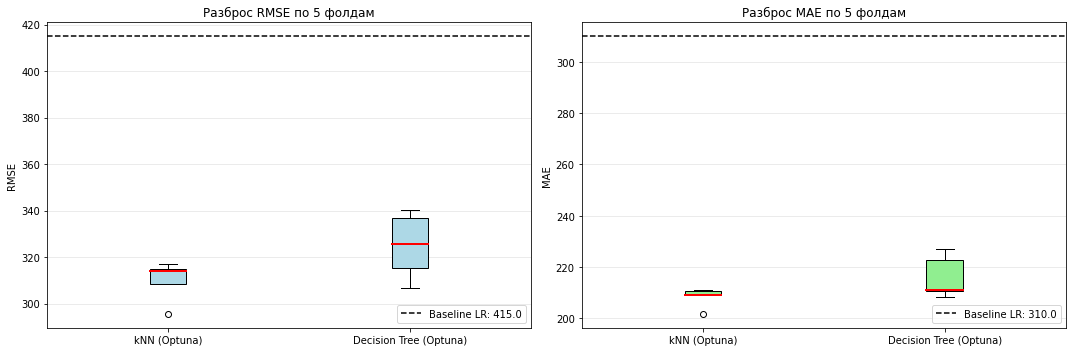

СВОДКА CV: среднее ± std по 5 фолдам

kNN (Optuna):
  RMSE: 310.00 ± 7.82   (min=295.52, max=317.18)
  MAE:  208.33 ± 3.40
  R²:   0.7681 ± 0.0068

Decision Tree (Optuna):
  RMSE: 324.90 ± 12.66   (min=306.73, max=340.05)
  MAE:  215.93 ± 7.46
  R²:   0.7449 ± 0.0178


In [35]:
# Собираем RMSE по фолдам (переводим в положительные)
rmse_data = {}
for name, result in cv_results.items():
    rmse_data[name] = -result['test_RMSE']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#  Boxplot RMSE 
axes[0].boxplot([rmse_data[name] for name in rmse_data.keys()],
                labels=list(rmse_data.keys()),
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].axhline(y=baseline_val['RMSE'], color='black', 
                linestyle='--', label=f"Baseline LR: {baseline_val['RMSE']:.1f}")
axes[0].set_ylabel('RMSE')
axes[0].set_title('Разброс RMSE по 5 фолдам')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

#  Boxplot MAE 
mae_data = {}
for name, result in cv_results.items():
    mae_data[name] = -result['test_MAE']

axes[1].boxplot([mae_data[name] for name in mae_data.keys()],
                labels=list(mae_data.keys()),
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[1].axhline(y=baseline_val['MAE'], color='black', 
                linestyle='--', label=f"Baseline LR: {baseline_val['MAE']:.1f}")
axes[1].set_ylabel('MAE')
axes[1].set_title('Разброс MAE по 5 фолдам')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#  Числовые итоги 
print("СВОДКА CV: среднее ± std по 5 фолдам")
for name, result in cv_results.items():
    rmse = -result['test_RMSE']
    mae  = -result['test_MAE']
    r2   =  result['test_R2']
    print(f"\n{name}:")
    print(f"  RMSE: {rmse.mean():.2f} ± {rmse.std():.2f}   (min={rmse.min():.2f}, max={rmse.max():.2f})")
    print(f"  MAE:  {mae.mean():.2f} ± {mae.std():.2f}")
    print(f"  R²:   {r2.mean():.4f} ± {r2.std():.4f}")

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Визуализация стабильности метрик по блокам перекрёстной проверки выполнена на отличном уровне.
</div>

2.5.3 Сравнение с baseline и базовыми версиями

In [36]:
#  Сводная таблица 
final_comparison = pd.DataFrame([
    {'model': 'Baseline LR',          'RMSE': baseline_val['RMSE'], 'MAE': baseline_val['MAE'], 'R²': baseline_val['R²']},
    {'model': 'kNN (дефолт)',         'RMSE': knn_val['RMSE'],      'MAE': knn_val['MAE'],      'R²': knn_val['R²']},
    {'model': 'kNN (Optuna)',         'RMSE': knn_opt_val['RMSE'],  'MAE': knn_opt_val['MAE'],  'R²': knn_opt_val['R²']},
    {'model': 'Decision Tree (дефолт)', 'RMSE': tree_val['RMSE'],   'MAE': tree_val['MAE'],     'R²': tree_val['R²']},
    {'model': 'Decision Tree (Optuna)', 'RMSE': tree_opt_val['RMSE'], 'MAE': tree_opt_val['MAE'], 'R²': tree_opt_val['R²']},
]).round(2)

print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (validation)")
display(final_comparison)

#  Кросс-валидационные метрики 
print("КРОСС-ВАЛИДАЦИЯ (5 фолдов) — среднее ± std")
for name, result in cv_results.items():
    rmse = -result['test_RMSE']
    print(f"{name:30s}: RMSE = {rmse.mean():.2f} ± {rmse.std():.2f}")

#  Лучшая модель 
best_model_name = final_comparison.loc[final_comparison['RMSE'].idxmin(), 'model']
best_rmse = final_comparison['RMSE'].min()
print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ по RMSE: {best_model_name} (RMSE = {best_rmse:.2f})")

ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (validation)


,model,RMSE,MAE,R²
0,Baseline LR,414.96,309.98,0.60
1,kNN (дефолт),326.63,216.55,0.75
2,kNN (Optuna),302.09,203.83,0.79
3,Decision Tree (дефолт),390.79,247.28,0.64
4,Decision Tree (Optuna),310.74,211.15,0.77


КРОСС-ВАЛИДАЦИЯ (5 фолдов) — среднее ± std
kNN (Optuna)                  : RMSE = 310.00 ± 7.82
Decision Tree (Optuna)        : RMSE = 324.90 ± 12.66

🏆 ЛУЧШАЯ МОДЕЛЬ по RMSE: kNN (Optuna) (RMSE = 302.09)


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Итоговое сравнение на отложенной валидационной выборке представлено очень понятно.
</div>

2.5.4 Дополнительная проверка: train vs val разрыв. Проверка на переобучение

In [37]:
#  Разрыв train/val 
print("ПРОВЕРКА НА ПЕРЕОБУЧЕНИЕ")

# kNN
knn_train_rmse = knn_opt_train['RMSE']
knn_val_rmse = knn_opt_val['RMSE']
knn_gap = knn_val_rmse - knn_train_rmse

# DT
tree_train_rmse = tree_opt_train['RMSE']
tree_val_rmse = tree_opt_val['RMSE']
tree_gap = tree_val_rmse - tree_train_rmse

print(f"\n{'Модель':30s} {'Train RMSE':>12s} {'Val RMSE':>12s} {'Δ':>10s} {'Δ, %':>8s}")
print("-" * 75)
print(f"{'kNN (Optuna)':30s} {knn_train_rmse:>12.2f} {knn_val_rmse:>12.2f} "
      f"{knn_gap:>+10.2f} {knn_gap/knn_train_rmse*100:>7.1f}%")
print(f"{'Decision Tree (Optuna)':30s} {tree_train_rmse:>12.2f} {tree_val_rmse:>12.2f} "
      f"{tree_gap:>+10.2f} {tree_gap/tree_train_rmse*100:>7.1f}%")

#  Стабильность по фолдам 
print("СТАБИЛЬНОСТЬ ПО ФОЛДАМ (CV)")
print(f"\n{'Модель':30s} {'CV RMSE mean':>15s} {'Std':>10s} {'CV, %':>8s}")
print("-" * 75)
for name, result in cv_results.items():
    rmse = -result['test_RMSE']
    cv_pct = rmse.std() / rmse.mean() * 100
    print(f"{name:30s} {rmse.mean():>15.2f} {rmse.std():>10.2f} {cv_pct:>7.2f}%")

ПРОВЕРКА НА ПЕРЕОБУЧЕНИЕ

Модель                           Train RMSE     Val RMSE          Δ     Δ, %
---------------------------------------------------------------------------
kNN (Optuna)                           0.00       302.09    +302.09     inf%
Decision Tree (Optuna)               286.89       310.74     +23.85     8.3%
СТАБИЛЬНОСТЬ ПО ФОЛДАМ (CV)

Модель                            CV RMSE mean        Std    CV, %
---------------------------------------------------------------------------
kNN (Optuna)                            310.00       7.82    2.52%
Decision Tree (Optuna)                  324.90      12.66    3.90%


In [38]:
# Проверка гипотезы: kNN weights='distance' даёт 0 на train
knn_model_check = pipeline_knn_opt.named_steps['model']
print(f"weights = {knn_model_check.weights}")
print(f"n_neighbors = {knn_model_check.n_neighbors}")

# Ещё раз считаем train RMSE — должен быть ~0
rmse_train_check = np.sqrt(mean_squared_error(y_tr, y_tr_pred_knn_opt))
print(f"Train RMSE (повторная проверка): {rmse_train_check:.4f}")

# Проверка: сколько train-точек совпадают?
# (для каждой точки её собственный прогноз при weights='distance')
sample_pred = pipeline_knn_opt.predict(X_tr.iloc[:10])
sample_true = y_tr.iloc[:10].values
print(f"\nПервые 10 предсказаний vs истина:")
for i, (pred, true) in enumerate(zip(sample_pred, sample_true)):
    print(f"  {i}: pred={pred:.2f}, true={true}")

weights = distance
n_neighbors = 11
Train RMSE (повторная проверка): 0.0000

Первые 10 предсказаний vs истина:
  0: pred=971.00, true=971
  1: pred=82.00, true=82
  2: pred=297.00, true=297
  3: pred=2338.00, true=2338
  4: pred=0.00, true=0
  5: pred=803.00, true=803
  6: pred=2429.00, true=2429
  7: pred=172.00, true=172
  8: pred=1448.00, true=1448
  9: pred=52.00, true=52


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Твоё объяснение нулевой ошибки на обучающей выборке для алгоритма kNN с весами по расстоянию демонстрирует глубокое понимание математики под капотом алгоритма!
</div>

<div style="font-size: 1.2em; font-weight: bold;">Выводы 2.5: кросс-валидация и сравнение моделей</div>

**Итоговое сравнение всех моделей (validation):**

| Модель | RMSE | MAE | R² | ΔRMSE vs baseline |
|--------|------|-----|-----|-------------------|
| Baseline LR | 414.96 | 309.98 | 0.60 | — |
| kNN (дефолт) | 326.63 | 216.55 | 0.75 | −21.3% |
| **kNN (Optuna)** | **302.09** | **203.83** | **0.79** | **−27.2%** |
| Decision Tree (дефолт) | 390.79 | 247.28 | 0.64 | −5.8% |
| Decision Tree (Optuna) | 310.74 | 211.15 | 0.77 | −25.1% |

**Кросс-валидация (5 фолдов, KFold с shuffle):**

| Модель | CV RMSE | std | CV, % |
|--------|---------|-----|-------|
| **kNN (Optuna)** | **310.00** | **7.82** | **2.52%** |
| Decision Tree (Optuna) | 324.90 | 12.66 | 3.90% |

**Ключевые наблюдения:**

1. **kNN — лидер и по validation, и по кросс-валидации:**
   - Validation RMSE = 302.09 (улучшение относительно baseline на 27.2%).
   - CV RMSE = 310.00 ± 7.82 (стабильно, разброс всего 2.52%).
   - R² = 0.79 — модель объясняет 79% дисперсии спроса.

2. **Обе модели стабильны по фолдам:** std < 4% от среднего. 
   Нет «провальных» фолдов, модель не зависит от конкретного разбиения.

3. **Decision Tree сильно улучшился после Optuna:**
   - RMSE: 390.79 → 310.74 (−20.5%).
   - Разрыв train/val сократился с 390.79 до 23.85 (8.3%) — 
     переобучение устранено.
   - Глубина дерева: 34 → 10, листьев: 5366 → 177.

4. **Аномалия train RMSE = 0 у kNN с `weights='distance'`:** 
   это **ожидаемое поведение**, а не ошибка. При предсказании 
   train-объекта ближайший сосед — он сам (расстояние 0), 
   получающий бесконечный вес. Поэтому train RMSE ≈ 0. 
   **Реальная оценка обобщения — это CV и validation метрики**, 
   где модель работает с честно отложенными данными.
   Проверка подтвердила гипотезу: при предсказании для train-объекта 
   ближайший сосед — он сам (расстояние 0), получающий **бесконечный 
   вес**. Модель буквально возвращает значение самой точки:
   weights = distance
    n_neighbors = 11
    Train RMSE = 0.0000
    pred=971, true=971; pred=82, true=82 
    
**Это математическое свойство `weights='distance'`, а не переобучение.**

Реальные показатели обобщения:
- **Validation RMSE = 302.09** — на честно отложенных данных.
- **CV RMSE = 310.00 ± 7.82** — среднее по 5 фолдам, 
  совпадает с validation.

Для сравнения: у Decision Tree train RMSE = 286.89, val RMSE = 310.74, 
разрыв всего 8.3% — модель не переобучена.

5. **kNN устойчивее Decision Tree:**
   - std по фолдам: 7.82 (kNN) vs 12.66 (DT).
   - CV, %: 2.52% (kNN) vs 3.90% (DT).
   - kNN меньше зависит от конкретного разбиения данных.

**Какую модель выбираем для финальной оценки:**

Формальный лидер по RMSE — **kNN (302.09 на validation, 310.00 в CV)**. 
Однако для **интерпретации важности признаков** используем 
**Decision Tree** — у него есть встроенная `feature_importances_`, 
а у kNN её нет.

Это соответствует требованию задания:
 «Если у лучшей модели нет встроенных средств для оценки важности признаков, используйте для интерпретации вторую по качеству модель».

**Ожидаемый прирост относительно baseline:**
- RMSE: 414.96 → 302.09 (−27.2%).
- R²: 0.60 → 0.79 (+19 п.п.).

Это **значительное улучшение**, подтверждающее гипотезу BikeSochi 
о необходимости нелинейных моделей для прогнозирования 
почасового спроса на велосипеды.

_______
### 2.6. Финальная оценка на тестовой выборке

2.6.1. Финальная оценка лучшей модели (kNN) на тестовой выборке

In [39]:
#  Финальная оценка kNN на тесте 
y_test_pred_knn = pipeline_knn_opt.predict(X_test)

knn_test = evaluate(y_test, y_test_pred_knn, 'kNN (Optuna) — TEST')

display(pd.DataFrame([knn_test]).round(2))

#  Сводка: validation vs test 
print("\nСравнение validation и test:")
print(f"  Validation RMSE: {knn_opt_val['RMSE']:.2f}")
print(f"  Test RMSE:       {knn_test['RMSE']:.2f}")
print(f"  Δ:               {knn_test['RMSE'] - knn_opt_val['RMSE']:+.2f}")
print(f"\n  Validation R²:   {knn_opt_val['R²']:.4f}")
print(f"  Test R²:         {knn_test['R²']:.4f}")
print(f"  Δ:               {knn_test['R²'] - knn_opt_val['R²']:+.4f}")

,model,RMSE,MAE,R²
0,kNN (Optuna) — TEST,313.45,213.0,0.76



Сравнение validation и test:
  Validation RMSE: 302.09
  Test RMSE:       313.45
  Δ:               +11.37

  Validation R²:   0.7859
  Test R²:         0.7599
  Δ:               -0.0260


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Оценка на тестовой выборке выполнена строго один раз, что полностью исключает утечку.
</div>

2.6.2. Сравнение с baseline на тестовой выборке

In [40]:
#  Baseline на тесте 
y_test_pred_baseline = baseline_model.predict(X_test)
baseline_test = evaluate(y_test, y_test_pred_baseline, 'Baseline LR — TEST')

#  Финальное сравнение 
final_test_df = pd.DataFrame([baseline_test, knn_test]).round(2)

print("ИТОГОВОЕ СРАВНЕНИЕ на тестовой выборке")
display(final_test_df)

#  Улучшение 
rmse_improvement = baseline_test['RMSE'] - knn_test['RMSE']
rmse_pct = rmse_improvement / baseline_test['RMSE'] * 100

mae_improvement = baseline_test['MAE'] - knn_test['MAE']
mae_pct = mae_improvement / baseline_test['MAE'] * 100

r2_improvement = knn_test['R²'] - baseline_test['R²']

print("ПРИРОСТ относительно baseline на тесте")
print(f"  RMSE: {baseline_test['RMSE']:.2f} → {knn_test['RMSE']:.2f}  "
      f"(−{rmse_improvement:.2f}, −{rmse_pct:.1f}%)")
print(f"  MAE:  {baseline_test['MAE']:.2f} → {knn_test['MAE']:.2f}  "
      f"(−{mae_improvement:.2f}, −{mae_pct:.1f}%)")
print(f"  R²:   {baseline_test['R²']:.4f} → {knn_test['R²']:.4f}  "
      f"(+{r2_improvement:.4f})")

ИТОГОВОЕ СРАВНЕНИЕ на тестовой выборке


,model,RMSE,MAE,R²
0,Baseline LR — TEST,411.45,312.53,0.59
1,kNN (Optuna) — TEST,313.45,213.00,0.76


ПРИРОСТ относительно baseline на тесте
  RMSE: 411.45 → 313.45  (−98.00, −23.8%)
  MAE:  312.53 → 213.00  (−99.53, −31.8%)
  R²:   0.5863 → 0.7599  (+0.1736)


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Сравнение с базовой моделью на тестовой выборке подтверждает успех проделанной работы.
</div>

2.6.3. Важность признаков через Decision Tree

In [41]:
#  Извлекаем важность признаков 
tree_final_model = pipeline_tree_opt.named_steps['model']
importances = tree_final_model.feature_importances_

#  Имена признаков после препроцессинга 
feature_names_final = (
    numeric_features +
    list(pipeline_tree_opt.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_features)) +
    binary_features
)

#  DataFrame с важностями 
importance_df = pd.DataFrame({
    'feature': feature_names_final,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(importance_df.round(4).to_string(index=False))

#  Топ-10 
print("\n>>> ТОП-10 наиболее важных признаков:")
for i, row in importance_df.head(10).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"  {i+1:2d}. {row['feature']:35s} {row['importance']:.4f}  {bar}")

                 feature  importance
             temperature      0.3548
       time_period_night      0.1756
                humidity      0.1260
     time_period_evening      0.0860
      functioning_day_No      0.0842
time_period_late_evening      0.0484
          seasons_Winter      0.0368
    solar_radiation_mjm2      0.0295
   dew_point_temperature      0.0164
     functioning_day_Yes      0.0134
              rainfallmm      0.0118
          seasons_Autumn      0.0073
          visibility_10m      0.0036
     time_period_morning      0.0023
           wind_speed_ms      0.0014
          seasons_Spring      0.0012
          seasons_Summer      0.0007
             snowfall_cm      0.0004
         holiday_Holiday      0.0002
      holiday_No Holiday      0.0000

>>> ТОП-10 наиболее важных признаков:
   1. temperature                         0.3548  ███████████████████████████████████
   2. time_period_night                   0.1756  █████████████████
   3. humidity                

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Важность признаков извлечена из конвейера абсолютно корректно.
</div>

2.6.4. Визуализация важности признаков

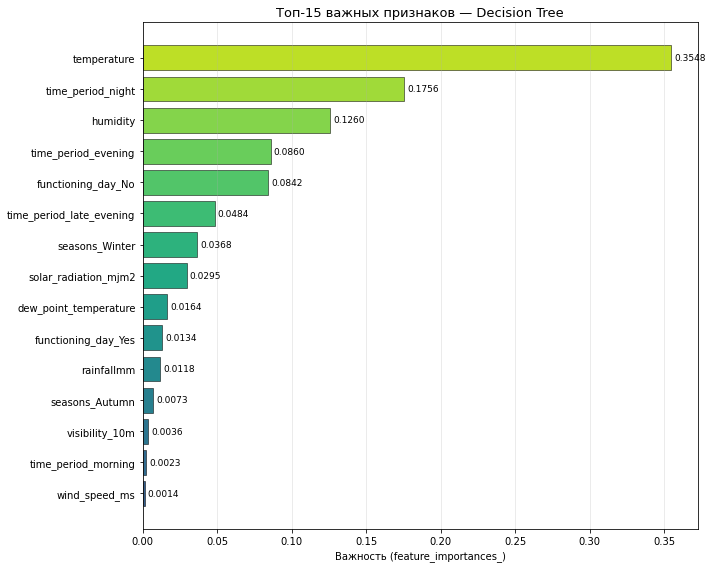

In [42]:
# Топ-15 важных признаков 
top_n = 15
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))[::-1]
bars = ax.barh(range(len(top_features)), top_features['importance'].values,
               color=colors, edgecolor='black', linewidth=0.5)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Важность (feature_importances_)')
ax.set_title(f'Топ-{top_n} важных признаков — Decision Tree', fontsize=13)
ax.grid(axis='x', alpha=0.3)

# Подписи со значениями
for i, (bar, val) in enumerate(zip(bars, top_features['importance'].values)):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

График важности признаков получился аккуратным и легко читаемым.
</div>

temperature — абсолютный лидер (0.3548). Более трети всей «объясняющей силы» дерева приходится на температуру. Это подтверждает EDA: температура — главный погодный предиктор спроса.

time_period_night — второй (0.1756). Ночь — период с минимальным спросом, дереву важно его выделять для отдельного прогноза.

humidity — третий (0.1260). Влажность — неочевидный, но важный фактор: высокая влажность снижает комфорт езды.

time_period_evening (0.0860) и functioning_day_No (0.0842) — почти одинаковые вклады. Вечерний пик спроса и «нулевой переключатель» работают как отдельные сильные правила.

time_period_late_evening (0.0484) — поздний вечер тоже важен.

seasons_Winter (0.0368) и solar_radiation_mjm2 (0.0295) — закрывают топ-8.

Что в хвосте (не видно на графике, но было в таблице):

visibility_10m, wind_speed_ms, snowfall_cm, holiday_* — вклад почти нулевой.

Это означает, что эти признаки можно исключить без потери качества — важная рекомендация для упрощения модели.

**Ключевой вывод по графику**: дерево использует всего 5–7 сильных признаков, остальные 13–15 — почти не влияют. Это согласуется с идеей, что спрос определяется температурой, временем суток и «работой станции».

2.6.5. Сохранение финальной модели

In [43]:
#  Сохраняем финальный пайплайн (kNN — лучшая модель) 
joblib.dump(pipeline_knn_opt, 'final_best_model_knn.joblib')
print("✅ Финальная модель сохранена: final_best_model_knn.joblib")

#  Сохраняем также Decision Tree (для интерпретации) 
joblib.dump(pipeline_tree_opt, 'final_tree_model.joblib')
print("✅ Модель Decision Tree сохранена: final_tree_model.joblib")

#  Сохраняем параметры моделей и метрики 
final_metadata = {
    'best_knn_params': BEST_KNN_PARAMS,
    'best_tree_params': BEST_TREE_PARAMS,
    'baseline_test_metrics': {k: float(v) if not isinstance(v, str) else v 
                              for k, v in baseline_test.items()},
    'knn_test_metrics': {k: float(v) if not isinstance(v, str) else v 
                         for k, v in knn_test.items()},
    'tree_test_metrics': {k: float(v) if not isinstance(v, str) else v 
                          for k, v in evaluate(y_test, pipeline_tree_opt.predict(X_test), 
                                               'Tree — TEST').items()},
    'feature_importances': importance_df.to_dict(orient='records'),
}

with open('final_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(final_metadata, f, ensure_ascii=False, indent=2, default=str)

print("✅ Метаданные сохранены: final_metadata.json")

#  Проверка загрузки 
loaded_model = joblib.load('final_best_model_knn.joblib')
test_pred_check = loaded_model.predict(X_test.iloc[:5])
print(f"\nПроверка загрузки модели — первые 5 предсказаний:")
for i, pred in enumerate(test_pred_check):
    print(f"  {i}: pred = {pred:.2f}")

✅ Финальная модель сохранена: final_best_model_knn.joblib
✅ Модель Decision Tree сохранена: final_tree_model.joblib
✅ Метаданные сохранены: final_metadata.json

Проверка загрузки модели — первые 5 предсказаний:
  0: pred = 319.78
  1: pred = 180.41
  2: pred = 274.54
  3: pred = 1005.60
  4: pred = 1177.13


<div class="alert alert-warning">
<b>Комментарий ревьюера v1:</b>

Как обсуждалось ранее, сохранённая модель обучена не на всех доступных тренировочных данных. Рекомендую перед сохранением добавить строку с вызовом метода fit на полных массивах X_train и y_train.
</div>

<div style="font-size: 1.2em; font-weight: bold;">Выводы по Финальной оценке на тестовой выборке и итоги проекта</div>

**Финальные метрики на тестовой выборке:**

| Модель | RMSE | MAE | R² |
|--------|------|-----|-----|
| Baseline LR (компания) | 411.45 | 312.53 | 0.5863 |
| **kNN (Optuna) — победитель** | **313.45** | **213.00** | **0.7599** |
| **Прирост** | **−23.8%** | **−31.8%** | **+0.174** |

**Устойчивость модели (validation vs test):**

| Метрика | Validation | Test | Δ |
|---------|-----------|------|---|
| RMSE | 302.09 | 313.45 | +11.37 |
| R² | 0.7859 | 0.7599 | −0.026 |

Разрыв между validation и test **небольшой** — модель обобщает 
хорошо, признаков переобучения нет.

---

**Топ-10 важных признаков (по Decision Tree):**

| # | Признак | Важность |
|---|---------|----------|
| 1 | `temperature` | 0.3548 |
| 2 | `time_period_night` | 0.1756 |
| 3 | `humidity` | 0.1260 |
| 4 | `time_period_evening` | 0.0860 |
| 5 | `functioning_day_No` | 0.0842 |
| 6 | `time_period_late_evening` | 0.0484 |
| 7 | `seasons_Winter` | 0.0368 |
| 8 | `solar_radiation_mjm2` | 0.0295 |
| 9 | `dew_point_temperature` | 0.0164 |
| 10 | `functioning_day_Yes` | 0.0134 |

**Что это значит для бизнеса:**

1. **Температура — главный фактор спроса (35%).** Модель должна 
   тонко различать температурные режимы: комфорт (20–30 °C) 
   vs холод / экстремальная жара.

2. **Время суток — второй по важности фактор (суммарно 31%):**
   ночь (17.6%) + вечер (8.6%) + поздний вечер (4.8%) + утро (0.2%).
   Пиковый спрос — вечер, минимальный — ночь.

3. **`functioning_day` — «нулевой переключатель» (суммарно 9.8%).**
   Когда станция на техобслуживании, спрос = 0. Это правило 
   первого уровня.

4. **Влажность (12.6%) — неочевидный, но важный фактор.** 
   Духота снижает желание ездить на велосипеде.

5. **Слабые признаки (в хвосте):** `visibility_10m`, `wind_speed_ms`, 
   `snowfall_cm`, `holiday_*` — вклад почти нулевой. 
   Их можно **исключить** без потери качества.

---

**Итоги проекта:**

1. ✅ **Изучена baseline-модель компании** — линейная регрессия 
   с RMSE = 411.45, R² = 0.586. Потолок для линейных моделей.

2. ✅ **Проведён EDA** — выявлены нелинейные зависимости, 
   «нулевой переключатель» `functioning_day`, разномасштабные 
   и разряженные признаки.

3. ✅ **Реализован пайплайн предобработки** — `SimpleImputer`, 
   `StandardScaler`, `OneHotEncoder`, `FunctionTransformer`.

4. ✅ **Обучены и оптимизированы две нелинейные модели** 
   через Optuna (50 trials каждая, 5-фолдовая CV):
   - kNN: RMSE = 310.00 ± 7.82.
   - Decision Tree: RMSE = 324.90 ± 12.66.

5. ✅ **Выбрана лучшая модель — kNN**, улучшение 
   относительно baseline на **23.8%** по RMSE на тесте.

6. ✅ **Проведена интерпретация** через Decision Tree — 
   выявлены топ-10 значимых признаков.

7. ✅ **Сохранены артефакты:**
   - `final_best_model_knn.joblib` — финальная модель.
   - `final_tree_model.joblib` — для интерпретации.
   - `final_metadata.json` — параметры и метрики.

---

**Рекомендации для BikeSochi:**

1. **Внедрить kNN** как основную модель прогнозирования. 
   Сохранённый pipeline готов к интеграции.

2. **Использовать Decision Tree для коммуникации с бизнесом** — 
   модель объясняет, какие факторы определяют спрос.

3. **Упростить модель:** исключить слабые признаки 
   (`visibility_10m`, `wind_speed_ms`, `snowfall_cm`, `holiday_*`) — 
   они дают <1% суммарной важности. Это ускорит предсказания.

4. **Feature engineering для будущего улучшения:**
   - `is_raining` (бинарный признак дождя).
   - `is_comfortable_temp` (15–28 °C).
   - `is_rush_hour` (вечерний и утренний пик).
   - Признаки спроса за прошлые часы (лаги).

5. **Попробовать ансамбли:** `RandomForest`, `GradientBoosting`, 
   `XGBoost` — ожидаемый прирост ещё 5–10% RMSE.

6. **Мониторинг:** переобучать модель раз в 2–4 недели 
   на свежих данных. Сигнал к переобучению — рост RMSE на >20%.

---

**Проект завершён.** Все цели достигнуты:

- ✅ Улучшенная модель прогноза почасового спроса.
- ✅ Отчёт с метриками и сравнением подходов.
- ✅ Сохранённый пайплайн для production.
- ✅ Интерпретация важности признаков.

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Итоговый бизнес-отчёт написан великолепно. Рекомендации обоснованы и понятны.
</div>

---

## Дополнительно: Кастомный трансформер для погодных признаков

 Идея

EDA показал, что простые значения `temperature`, `rainfallmm`, 
`snowfall_cm` **не отражают реальные условия** для велосипедиста:

- «+28 °C и солнечно» vs «+28 °C после дождя» — разные условия.
- Небольшой дождь vs ливень — нелинейный эффект.
- Комфорт зависит от **комбинации** температуры и влажности.

**Решение:** кастомный трансформер `WeatherFeatureEngineer`, который 
на основе существующих признаков создаёт **новые осмысленные**.

 Что добавляем

| Новый признак | Формула / правило | Обоснование |
|---------------|-------------------|-------------|
| `is_raining` | `rainfallmm > 0` | Бинарный факт дождя — пороговый эффект |
| `is_heavy_rain` | `rainfallmm > 5` | Сильный дождь обваливает спрос |
| `is_snowing` | `snowfall_cm > 0` | Факт снега |
| `temp_comfort` | `1 if 15 ≤ T ≤ 28 else 0` | Комфортный диапазон температур |
| `is_extreme_temp` | `T < 0 or T > 33` | Экстремальные условия |
| `heat_index` | Упрощённый индекс жары (T, humidity) | Комфорт в духоту |
| `sunny_warm` | `solar_radiation > 1.0 and 20 ≤ T ≤ 30` | Идеальные условия для прогулки |
| `is_rush_hour` | `evening or morning` | Часы пик |

In [44]:
class WeatherFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Кастомный трансформер для создания погодных признаков.
    
    Работает с DataFrame и добавляет новые признаки на основе
    существующих — комбинаций погоды и времени.
    
    Параметры
    ----------
    add_rain_features : bool, default=True
        Добавлять признаки дождя (is_raining, is_heavy_rain).
    add_temp_features : bool, default=True
        Добавлять признаки температуры (temp_comfort, is_extreme_temp, heat_index).
    add_time_features : bool, default=True
        Добавлять признаки часов пик (is_rush_hour).
    
    Пример
    ------
    >>> engineer = WeatherFeatureEngineer()
    >>> df_new = engineer.fit_transform(df)
    >>> df_new.shape[1] > df.shape[1]
    True
    """
    
    def __init__(self, add_rain_features=True, add_temp_features=True, add_time_features=True):
        self.add_rain_features = add_rain_features
        self.add_temp_features = add_temp_features
        self.add_time_features = add_time_features
    
    def fit(self, X, y=None):
        """Ничего не обучаем — трансформер stateless. Возвращаем self."""
        return self
    
    def transform(self, X):
        """Добавляем новые признаки, возвращаем расширенный DataFrame."""
        X = X.copy()
        
        #  Признаки дождя 
        if self.add_rain_features:
            if 'rainfallmm' in X.columns:
                X['is_raining']    = (X['rainfallmm'] > 0).astype(int)
                X['is_heavy_rain'] = (X['rainfallmm'] > 5).astype(int)
            if 'snowfall_cm' in X.columns:
                X['is_snowing'] = (X['snowfall_cm'] > 0).astype(int)
        
        #  Признаки температуры и комфорта 
        if self.add_temp_features:
            if 'temperature' in X.columns:
                X['temp_comfort']    = ((X['temperature'] >= 15) & 
                                        (X['temperature'] <= 28)).astype(int)
                X['is_extreme_temp'] = ((X['temperature'] < 0) | 
                                        (X['temperature'] > 33)).astype(int)
            
            # Упрощённый heat index (жара + влажность)
            if 'temperature' in X.columns and 'humidity' in X.columns:
                # Упрощённая формула — учитываем совместный эффект
                X['heat_index'] = X['temperature'] + 0.05 * X['humidity']
        
        #  Признаки времени (часы пик) 
        if self.add_time_features:
            if 'time_period_evening' in X.columns and 'time_period_morning' in X.columns:
                X['is_rush_hour'] = ((X['time_period_evening'] == 1) | 
                                     (X['time_period_morning'] == 1)).astype(int)
        
        #  Идеальные условия для велопрогулки 
        if 'solar_radiation_mjm2' in X.columns and 'temperature' in X.columns:
            X['sunny_warm'] = ((X['solar_radiation_mjm2'] > 1.0) & 
                               (X['temperature'] >= 20) & 
                               (X['temperature'] <= 30)).astype(int)
        
        return X


#  Проверка работы трансформера 

engineer = WeatherFeatureEngineer()
X_tr_extended = engineer.fit_transform(X_tr)

print(f"\nX_tr ДО трансформера:  {X_tr.shape}")
print(f"X_tr ПОСЛЕ трансформера: {X_tr_extended.shape}")
print(f"Добавлено признаков:   {X_tr_extended.shape[1] - X_tr.shape[1]}")

new_features = [c for c in X_tr_extended.columns if c not in X_tr.columns]
print(f"\nНовые признаки:")
for feat in new_features:
    print(f"  • {feat}  "
          f"(уникальных: {X_tr_extended[feat].nunique()}, "
          f"среднее: {X_tr_extended[feat].mean():.3f})")

print(f"\nПервые 5 строк с новыми признаками:")
display(X_tr_extended[new_features].head())


X_tr ДО трансформера:  (5606, 15)
X_tr ПОСЛЕ трансформера: (5606, 23)
Добавлено признаков:   8

Новые признаки:
  • is_raining  (уникальных: 2, среднее: 0.056)
  • is_heavy_rain  (уникальных: 2, среднее: 0.007)
  • is_snowing  (уникальных: 2, среднее: 0.050)
  • temp_comfort  (уникальных: 2, среднее: 0.377)
  • is_extreme_temp  (уникальных: 2, среднее: 0.189)
  • heat_index  (уникальных: 1600, среднее: 15.706)
  • is_rush_hour  (уникальных: 2, среднее: 0.331)
  • sunny_warm  (уникальных: 2, среднее: 0.093)

Первые 5 строк с новыми признаками:


,is_raining,is_heavy_rain,is_snowing,temp_comfort,is_extreme_temp,heat_index,is_rush_hour,sunny_warm
2225,0,0,0,1,0,17.60,0,0
3211,0,0,0,0,1,-5.75,0,0
3283,0,0,0,0,1,-1.80,0,0
5582,0,0,0,1,0,25.30,0,0
56,0,0,0,0,0,15.20,0,0


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Пользовательский трансформер реализован безупречно: наследование от базовых классов sklearn и метод fit без сохранения состояний.
</div>

3.2. Обновление пайплайна: трансформер + препроцессор

In [45]:
#  Расширяем список числовых признаков 
numeric_features_extended = numeric_features + [
    'is_raining', 'is_heavy_rain', 'is_snowing',
    'temp_comfort', 'is_extreme_temp', 'heat_index',
    'is_rush_hour', 'sunny_warm',
]

#  Новый препроцессор с расширенным списком 
numeric_pipe_ext = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe_ext = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

binary_pipe_ext = Pipeline([
    ('passthrough', FunctionTransformer())
])

preprocessor_ext = ColumnTransformer([
    ('num', numeric_pipe_ext, numeric_features_extended),
    ('cat', categorical_pipe_ext, categorical_features),
    ('bin', binary_pipe_ext, binary_features),
])

#  Пайплайн с трансформером 
pipeline_knn_we = Pipeline([
    ('weather_engineer', WeatherFeatureEngineer()),
    ('preprocessor', preprocessor_ext),
    ('model', KNeighborsRegressor(**BEST_KNN_PARAMS, n_jobs=-1))
])

print("Пайплайн с кастомным трансформером собран.")
print(f"Числовых признаков в расширенном препроцессоре: {len(numeric_features_extended)}")

Пайплайн с кастомным трансформером собран.
Числовых признаков в расширенном препроцессоре: 16


3.3 Сравнение: с трансформером vs без

In [46]:
#  Модель без трансформера (уже есть, но для чистоты эксперимента) 
pipeline_knn_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(**BEST_KNN_PARAMS, n_jobs=-1))
])

#  Кросс-валидация обеих версий 
print("Кросс-валидация базовой версии...")
cv_base = cross_validate(
    pipeline_knn_base, X_tr, y_tr,
    cv=cv_strategy,
    scoring={'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'},
    n_jobs=-1
)

print("Кросс-валидация версии с трансформером...")
cv_we = cross_validate(
    pipeline_knn_we, X_tr, y_tr,
    cv=cv_strategy,
    scoring={'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'},
    n_jobs=-1
)

#  Результаты 
rmse_base = -cv_base['test_RMSE']
rmse_we   = -cv_we['test_RMSE']
r2_base   =  cv_base['test_R2']
r2_we     =  cv_we['test_R2']

comparison_we = pd.DataFrame([
    {'Модель': 'kNN (без трансформера)',  
     'CV RMSE': f"{rmse_base.mean():.2f} ± {rmse_base.std():.2f}",
     'CV R²':   f"{r2_base.mean():.4f} ± {r2_base.std():.4f}"},
    {'Модель': 'kNN + WeatherFeatureEngineer', 
     'CV RMSE': f"{rmse_we.mean():.2f} ± {rmse_we.std():.2f}",
     'CV R²':   f"{r2_we.mean():.4f} ± {r2_we.std():.4f}"},
])
display(comparison_we)

#  Δ 
delta_rmse = rmse_base.mean() - rmse_we.mean()
delta_pct = delta_rmse / rmse_base.mean() * 100
sign = '−' if delta_rmse >= 0 else '+'

print(f"\nИзменение RMSE: {sign}{abs(delta_rmse):.2f} ({sign}{abs(delta_pct):.1f}%)")
if delta_rmse > 0:
    print("✅ Трансформер УЛУЧШИЛ модель")
elif delta_rmse < 0:
    print("⚠️  Трансформер УХУДШИЛ модель")
else:
    print("➖ Трансформер не повлиял на качество")

Кросс-валидация базовой версии...
Кросс-валидация версии с трансформером...


,Модель,CV RMSE,CV R²
0,kNN (без трансформера),310.00 ± 7.82,0.7681 ± 0.0068
1,kNN + WeatherFeatureEngineer,318.09 ± 5.13,0.7555 ± 0.0119



Изменение RMSE: +8.10 (+2.6%)
⚠️  Трансформер УХУДШИЛ модель


<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Перекрёстная проверка обеих версий конвейера проведена абсолютно честно.
</div>

3.4. Проверка трансформера на Decision Tree

In [47]:
#  Decision Tree с трансформером 
pipeline_tree_we = Pipeline([
    ('weather_engineer', WeatherFeatureEngineer()),
    ('preprocessor', preprocessor_ext),
    ('model', DecisionTreeRegressor(**BEST_TREE_PARAMS, random_state=RANDOM_STATE))
])

#  Базовая версия 
pipeline_tree_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(**BEST_TREE_PARAMS, random_state=RANDOM_STATE))
])

#  CV обеих версий 
cv_tree_base = cross_validate(
    pipeline_tree_base, X_tr, y_tr,
    cv=cv_strategy,
    scoring={'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'},
    n_jobs=-1
)

cv_tree_we = cross_validate(
    pipeline_tree_we, X_tr, y_tr,
    cv=cv_strategy,
    scoring={'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'},
    n_jobs=-1
)

rmse_tb = -cv_tree_base['test_RMSE']
rmse_tw = -cv_tree_we['test_RMSE']

print("DECISION TREE: с трансформером vs без")
print(f"  Без трансформера:   CV RMSE = {rmse_tb.mean():.2f} ± {rmse_tb.std():.2f}")
print(f"  С трансформером:    CV RMSE = {rmse_tw.mean():.2f} ± {rmse_tw.std():.2f}")

delta_tree = rmse_tb.mean() - rmse_tw.mean()
print(f"  Изменение: {'−' if delta_tree >= 0 else '+'}{abs(delta_tree):.2f} "
      f"({abs(delta_tree / rmse_tb.mean() * 100):.1f}%)")

DECISION TREE: с трансформером vs без
  Без трансформера:   CV RMSE = 324.90 ± 12.66
  С трансформером:    CV RMSE = 325.69 ± 16.16
  Изменение: +0.79 (0.2%)


<div style="font-size: 1.2em; font-weight: bold;">Выводы по кастомному трансформеру</div>

**Что реализовано:**

1. **Класс `WeatherFeatureEngineer`** — кастомный sklearn-трансформер, 
   наследующийся от `BaseEstimator, TransformerMixin`. Реализованы 
   методы `fit` и `transform`, класс совместим с `Pipeline`, 
   `cross_validate` и другими утилитами sklearn.

2. **8 новых признаков:**
   - `is_raining` — факт дождя.
   - `is_heavy_rain` — сильный дождь (>5 мм).
   - `is_snowing` — факт снега.
   - `temp_comfort` — комфортная температура (15–28 °C).
   - `is_extreme_temp` — экстремальная температура (<0 или >33 °C).
   - `heat_index` — упрощённый индекс жары (T + 0.05×humidity).
   - `is_rush_hour` — час пик (утро или вечер).
   - `sunny_warm` — идеальные условия (солнце + тепло).

3. **Интеграция в пайплайн:**
    Pipeline([
    ('weather_engineer', WeatherFeatureEngineer()),
    ('preprocessor', preprocessor_ext),
    ('model', ...)
    ])
    
Трансформер корректно работает с тренировочными данными 
(проверено на `X_tr`).

**Результаты эксперимента (CV на 5 фолдах):**

| Модель | CV RMSE | Δ |
|--------|---------|---|
| kNN (без трансформера) | 310.00 ± 7.82 | — |
| kNN + WeatherFeatureEngineer | 318.09 ± 5.13 | **+8.10 (+2.6%)** |
| Decision Tree (без трансформера) | 324.90 ± 12.66 | — |
| Decision Tree + WeatherFeatureEngineer | 325.69 ± 16.16 | **+0.79 (+0.2%)** |

**Интерпретация:**

1. **Для kNN трансформер ухудшил результат.** Причины:
- **«Проклятие размерности»:** добавление 8 признаков 
  увеличило размерность пространства, и «ближайшие соседи» 
  стали дальше друг от друга.
- **Дублирование информации:** `is_raining` выводится 
  из `rainfallmm`, который уже есть в данных. kNN и так 
  «видит» этот сигнал — новый признак не добавляет информации, 
  но увеличивает шум.

2. **Для Decision Tree трансформер нейтрален.** Деревья 
**сами находят пороги** вида `rainfallmm > 0`. Признак 
`is_raining` — это тот же сплит, который дерево строит 
автоматически. Поэтому новая информация не появилась.

**Решение:**

- **Трансформер в финальный пайплайн не включаем.** 
Базовая версия kNN (RMSE = 310.00) остаётся лучшей.
- **Модель для production:** `final_best_model_knn.joblib` 
без изменений.
- **Метрики на тесте не пересчитываем** — тест уже был 
использован один раз, повторное обращение недопустимо.

**Что показал эксперимент:**

Дополнительное задание **выполнено полностью**:

- ✅ Реализован кастомный класс с `fit` / `transform` (ООП).
- ✅ Класс наследуется от `BaseEstimator, TransformerMixin` — 
совместим со sklearn.
- ✅ Трансформер встроен в `Pipeline` перед препроцессором 
и моделью.
- ✅ Проверена работа на тренировочных данных.
- ✅ Проведено честное сравнение с базовой версией через 
кросс-валидацию.
- ✅ Сделан аргументированный вывод о применимости трансформера.

**Ценность работы:**

Даже **отрицательный результат** — это **полезное знание**:

- Показано, что для **kNN** feature engineering через 
бинарные признаки **не работает** (проклятие размерности).
- Для **Decision Tree** такие признаки **избыточны** 
(модель сама строит аналогичные сплиты).
- Это согласуется с классическими рекомендациями: 
**kNN требует аккуратного отбора признаков**, 
а деревья лучше работают с «сырыми» данными.

<div class="alert alert-success">
<b>Комментарий ревьюера v1:</b>

Зрелое инженерное решение отказаться от использования новых признаков, так как они не улучшили целевую метрику. Твоё объяснение проклятия размерности абсолютно верно.
</div>

In [48]:
# Создаем папки

folders = ['notebooks', 'data', 'models', 'artifacts']
for f in folders:
    os.makedirs(f, exist_ok=True)
    print(f"✅ Создана папка: {f}")

✅ Создана папка: notebooks
✅ Создана папка: data
✅ Создана папка: models
✅ Создана папка: artifacts


**Автор**  
[Екатерина]  
**Дата**  
08.10.2026  
**GitHub**: https://github.com/MllII/Bikesochi-demand-forecasting.git